# Import Libraries and Functions

In [1]:
import sys
import importlib
import joblib
import os
import math
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.backends.backend_pdf import PdfPages
import time
from tqdm import tqdm
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

2026-09-09 13:34:51.282353: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-09 13:34:51.315547: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-09 13:34:51.315577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-09 13:34:51.316598: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 13:34:51.322652: I tensorflow/core/platform/cpu_feature_guar

In [2]:
sys.path.append("../analysis_tools")

In [3]:
# importlib.reload(data_extraction)
from data_extraction import DataExtraction2D
# import data_plot

# importlib.reload(data_plot)  
from data_plot import DataPlot

import data_calculation

# import modelData_processor
# importlib.reload(modelData_processor)
from modelData_processor import ModelDataProcessor

# import model_Analysis
# importlib.reload(model_Analysis)
from model_Analysis import ModelAnalysis

# importlib.reload(data_plot)  
from data_plot import DataPlot
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
def get_result(data_df, wind_value,direction_value,initial_wave_h_value,initial_wave_d_value,loc):

    filtered_df = data_df[
        (data_df['wind'] == wind_value) &
        (data_df['wind_direction'] == direction_value) &
        (data_df['initial_wave_h'] == initial_wave_h_value) &
        (data_df['initial_wave_d'] == initial_wave_d_value)
    ]
    if loc != 'entire':
        return filtered_df['x_wforce'].iloc[loc], filtered_df['y_wforce'].iloc[loc], filtered_df['Hsig'].iloc[loc], filtered_df['dist'].iloc[loc]
    else:
        return filtered_df['x_wforce'], filtered_df['y_wforce'], filtered_df['Hsig'], filtered_df['dist']

import itertools

def convert_wind_components(speed, direction):
    # Convert wind direction to radians
    direction_rad = np.deg2rad(direction)
    # Calculate x and y components of the wind speed
    x_wind = speed * np.cos(direction_rad)
    y_wind = speed * np.sin(direction_rad)
    return x_wind, y_wind
    
def load_and_scale_new_data(new_b_train, scaler_path_0_1, scaler_path_2):
    """
    Load the saved scalers and apply scaling to new data.
    
    Parameters:
    - new_b_train: np.array, new input data with 4 columns.
    - scaler_path_0_1: str, path to load MinMaxScaler for columns 0 and 1.
    - scaler_path_2: str, path to load MinMaxScaler for column 2.
    - scaler_path_3: str, path to load scaling factor for column 3.
    
    Returns:
    - new_b_train_scaled: np.array, scaled new data.
    """
    # Load the saved MinMaxScaler for columns 0 and 1
    scaler_0_1 = joblib.load(scaler_path_0_1)
    
    # Load the saved MinMaxScaler for column 2
    scaler_2 = joblib.load(scaler_path_2)
    
    # # Load the custom scaling factor for column 3
    # scaling_factor_3 = joblib.load(scaler_path_3)
    
    # Apply scaling to columns 0 and 1 using the loaded scaler
    new_scaled_0_1 = scaler_0_1.transform(new_b_train[:, [0, 1]])
    
    # Apply scaling to column 2 using the loaded scaler
    new_scaled_2 = scaler_2.transform(new_b_train[:, [2]].reshape(-1, 1))
    
    # # Apply custom scaling to column 3 by dividing by the loaded factor (360)
    # new_scaled_3 = new_b_train[:, [3]] / scaling_factor_3
    
    # Combine the scaled columns back together
    # new_b_train_scaled = np.hstack((new_scaled_0_1, new_scaled_2, new_scaled_3.reshape(-1, 1)))
    new_b_train_scaled = np.hstack((new_scaled_0_1, new_scaled_2, new_b_train[:, [3, 4]]))
    
    return new_b_train_scaled
def trunk_scale_and_reload(t_train, t_val=None, save_scalers=True, reload_scalers=False, scaler_path_0=None, scaler_path_1=None):
        """
        Scales t_train and optionally t_val columns independently to range [0, 1],
        with the ability to save and reload scalers.
        
        Args:
            t_train (numpy.ndarray): Training data with two columns to scale.
            t_val (numpy.ndarray, optional): Validation data with two columns to scale. Defaults to None.
            save_scalers (bool): Whether to save the scalers for later use. Defaults to True.
            reload_scalers (bool): Whether to reload scalers from the provided paths. Defaults to False.
            scaler_path_0 (str): Path to save or reload the scaler for column 0.
            scaler_path_1 (str): Path to save or reload the scaler for column 1.
        
        Returns:
            tuple: Scaled t_train and optionally t_val arrays.
        """
        # Initialize scalers
        if reload_scalers:
            # Reload saved scalers
            if scaler_path_0 and scaler_path_1:
                scaler_col_0 = joblib.load(scaler_path_0)
                scaler_col_1 = joblib.load(scaler_path_1)
            else:
                raise ValueError("Scaler paths must be provided for reloading scalers.")
        else:
            # Initialize new scalers for each column
            scaler_col_0 = MinMaxScaler(feature_range=(0, 1))  # For column 0
            scaler_col_1 = MinMaxScaler(feature_range=(0, 1))  # For column 1
            
            # Fit scalers on t_train
            scaler_col_0.fit(t_train[:, 0].reshape(-1, 1))
            scaler_col_1.fit(t_train[:, 1].reshape(-1, 1))
            
            # Save scalers if required
            if save_scalers:
                if scaler_path_0:
                    joblib.dump(scaler_col_0, scaler_path_0)
                if scaler_path_1:
                    joblib.dump(scaler_col_1, scaler_path_1)
        
        # Scale t_train using the scalers
        t_train_scaled_col_0 = scaler_col_0.transform(t_train[:, 0].reshape(-1, 1))
        t_train_scaled_col_1 = scaler_col_1.transform(t_train[:, 1].reshape(-1, 1))
        t_train_scaled = np.hstack([t_train_scaled_col_0, t_train_scaled_col_1])
        
        # Scale t_val if provided
        if t_val is not None:
            t_val_scaled_col_0 = scaler_col_0.transform(t_val[:, 0].reshape(-1, 1))
            t_val_scaled_col_1 = scaler_col_1.transform(t_val[:, 1].reshape(-1, 1))
            t_val_scaled = np.hstack([t_val_scaled_col_0, t_val_scaled_col_1])
            return t_train_scaled, t_val_scaled
        
        return t_train_scaled

# Data Loading and Mesh Plot

## Data Loading

In [5]:
df_xp= pd.read_csv('../Data/DUCK_SWAN_Data/2d_duck_xp.txt', sep='\t', header=None)
df_yp= pd.read_csv('../Data/DUCK_SWAN_Data/2d_duck_yp.txt', sep='\t', header=None)
xp_vector_train = df_xp.values.flatten()
yp_vector_train = df_yp.values.flatten()

In [6]:
df_xp= pd.read_csv('../Data/DUCK_SWAN_CrossGridValidation/2d_duck_xp.txt', sep='\t', header=None)
df_yp= pd.read_csv('../Data/DUCK_SWAN_CrossGridValidation/2d_duck_yp.txt', sep='\t', header=None)
xp_vector = df_xp.values.flatten()
yp_vector = df_yp.values.flatten()

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cross_grid_validation(xp_train, yp_train, xp_val, yp_val):
    plt.figure(figsize=(10, 8))
    
    plt.scatter(xp_val, yp_val, 
            color='royalblue', s=200, marker='x', label='Refined Mesh (Fine)', 
            alpha=0.9)

    plt.scatter(xp_train, yp_train, 
                color='crimson', s=200, marker='o',label='Coarse Training Mesh', 
                alpha=0.5, edgecolors='none')
    
    mid_idx = len(xp_train) // 2
    cx, cy = xp_train[mid_idx], yp_train[mid_idx]
    
    plt.xlim(cx - 200, cx + 100)
    plt.ylim(cy - 200, cy + 100)

    # Labels and Style
    plt.xlabel('X (m)', fontsize=12)
    plt.ylabel('Y (m)', fontsize=12)
    plt.title('Cross-Grid Validation: Mesh Refinement', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    # plt.savefig('./Results/cross_grid_zoom.pdf', dpi=300)
    plt.show()


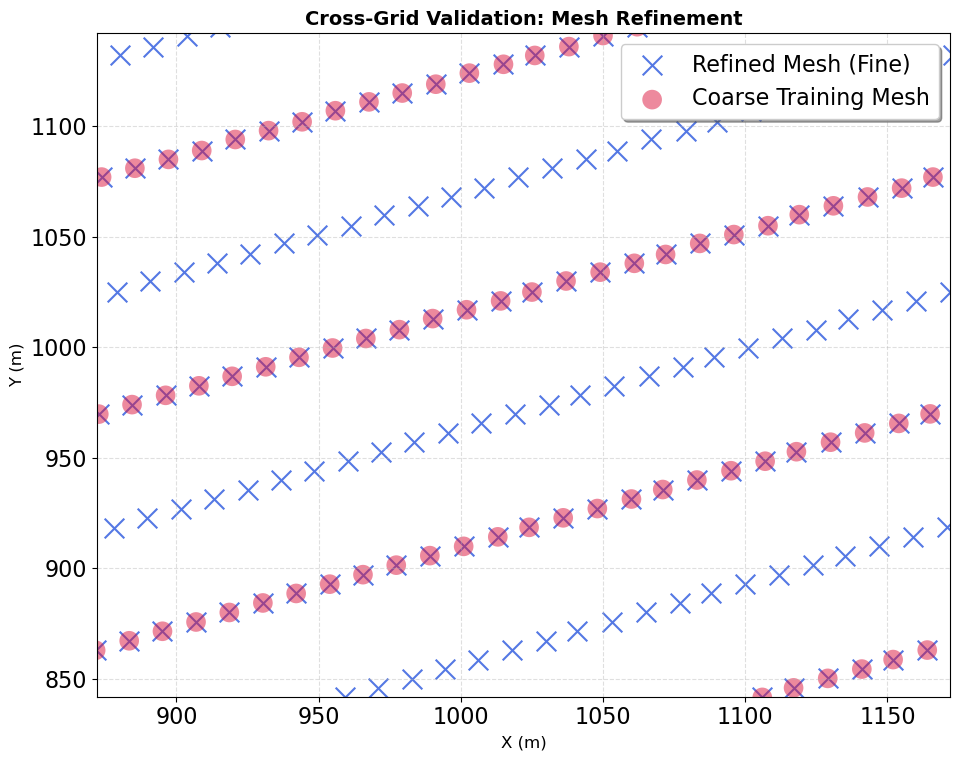

In [8]:
plot_cross_grid_validation(xp_vector_train, yp_vector_train, xp_vector, yp_vector)

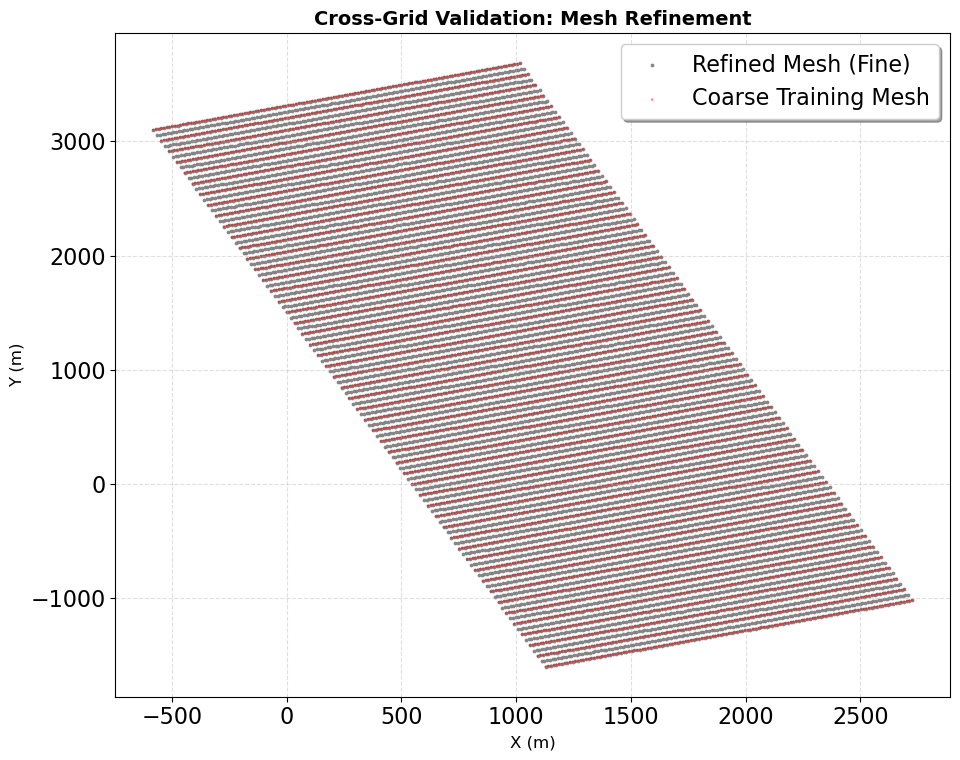

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cross_grid_validation(xp_train, yp_train, xp_val, yp_val):
    plt.figure(figsize=(10, 8))
    
    plt.scatter(xp_val, yp_val, 
            color='grey', s=3, marker='o', label='Refined Mesh (Fine)', 
            alpha=0.9)

    plt.scatter(xp_train, yp_train, 
                color='red', s=3, marker='o',label='Coarse Training Mesh', 
                alpha=0.5, edgecolors='none')
    
    mid_idx = len(xp_train) // 2
    cx, cy = xp_train[mid_idx], yp_train[mid_idx]
    
    # plt.xlim(cx - 200, cx + 100)
    # plt.ylim(cy - 200, cy + 100)

    

    # Labels and Style
    plt.xlabel('X (m)', fontsize=12)
    plt.ylabel('Y (m)', fontsize=12)
    plt.title('Cross-Grid Validation: Mesh Refinement', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    # plt.savefig('./Results/cross_grid_zoom_grey.pdf', dpi=300)
    plt.show()

plot_cross_grid_validation(xp_vector_train, yp_vector_train, xp_vector, yp_vector)


## Original Training Data

In [10]:
data_extractor = DataExtraction2D()

In [11]:
df_output_train = data_extractor.GetScenariosToPD(filename = "../Data/DUCK_SWAN_Data/swan_Log_DUCK.txt")

     Wind Value Wind Direction Wave Height Wave Direction  Iterations
0             1              0         1.6            -20          13
1             1              0         1.6              0          14
2             1              0         1.6             20          16
3             1              0         1.6             40          18
4             1              0         1.6             60          19
...         ...            ...         ...            ...         ...
3835          8            315         2.6             80          19
3836          8            315         2.6            100          18
3837          8            315         2.6            120          18
3838          8            315         2.6            140          15
3839          8            315         2.6            160          14

[3840 rows x 5 columns]


In [12]:
df_converged_train = df_output_train[df_output_train['Iterations'] != 50]
print(df_converged_train)

     Wind Value Wind Direction Wave Height Wave Direction  Iterations
0             1              0         1.6            -20          13
1             1              0         1.6              0          14
2             1              0         1.6             20          16
3             1              0         1.6             40          18
4             1              0         1.6             60          19
...         ...            ...         ...            ...         ...
3835          8            315         2.6             80          19
3836          8            315         2.6            100          18
3837          8            315         2.6            120          18
3838          8            315         2.6            140          15
3839          8            315         2.6            160          14

[3840 rows x 5 columns]


In [13]:
relevant_keys_train = set(
    zip(
        df_converged_train["Wind Value"].astype(int),
        df_converged_train["Wind Direction"].astype(int),
        df_converged_train["Wave Height"].astype(float),
        df_converged_train["Wave Direction"].astype(int),
    )
)

In [14]:
hsig_data_train = data_extractor.get_specific_data("../Data/DUCK_SWAN_Data/DUCK_training_hsig.txt", 'hsig', relevant_keys_train)
forces_data_train = data_extractor.get_specific_data("../Data/DUCK_SWAN_Data/DUCK_training_forces.txt", 'forces', relevant_keys_train)

In [15]:
df_train = data_extractor.DataConcat(relevant_keys_train, hsig_data_train, forces_data_train)

In [16]:
with open("../Data/DUCK_SWAN_Data/DUCK_dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

train_data_train = loaded_data["train"]
val_data_train = loaded_data["val"]
test_data_train = loaded_data["test"]

In [17]:
df_train["key"] = list(zip(df_train["Wind Value"], df_train["Wind Direction"], df_train["Wave Height"], df_train["Wave Direction"]))
test_df_train = df_train[df_train["key"].isin(test_data_train)]

In [18]:
train_df_train = df_train[df_train["key"].isin(train_data_train )]

## Fine Mesh

In [19]:
data_extractor = DataExtraction2D()

In [20]:
df_output = data_extractor.GetScenariosToPD(filename = "../Data/DUCK_SWAN_CrossGridValidation/output_log_fineGrid.txt")

    Wind Value Wind Direction Wave Height Wave Direction  Iterations
0            1              0         2.2            -20          15
1            4             45         1.8             80          17
2            5            225         2.6             20          20
3            1             90         1.8             40          18
4            6            135         2.2             60          18
..         ...            ...         ...            ...         ...
571          4            315         1.6            140          13
572          5             45         1.6            100          16
573          2              0         1.6            -20          13
574          6            180         2.0            120          16
575          8            225         1.6            160          11

[576 rows x 5 columns]


In [21]:
df_converged = df_output[df_output['Iterations'] != 50]
print(df_converged)

    Wind Value Wind Direction Wave Height Wave Direction  Iterations
0            1              0         2.2            -20          15
1            4             45         1.8             80          17
2            5            225         2.6             20          20
3            1             90         1.8             40          18
4            6            135         2.2             60          18
..         ...            ...         ...            ...         ...
571          4            315         1.6            140          13
572          5             45         1.6            100          16
573          2              0         1.6            -20          13
574          6            180         2.0            120          16
575          8            225         1.6            160          11

[576 rows x 5 columns]


In [22]:
relevant_keys = set(
    zip(
        df_converged["Wind Value"].astype(int),
        df_converged["Wind Direction"].astype(int),
        df_converged["Wave Height"].astype(float),
        df_converged["Wave Direction"].astype(int),
    )
)

In [23]:
hsig_data = data_extractor.get_specific_data("../Data/DUCK_SWAN_CrossGridValidation/DUCK_training_hsig.txt", 'hsig', relevant_keys)
forces_data = data_extractor.get_specific_data("../Data/DUCK_SWAN_CrossGridValidation/DUCK_training_forces.txt", 'forces', relevant_keys)

In [24]:
df = data_extractor.DataConcat(relevant_keys, hsig_data, forces_data)

In [25]:
with open("../Data/DUCK_SWAN_Data/DUCK_dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

train_data = loaded_data["train"]
val_data = loaded_data["val"]
test_data = loaded_data["test"]

In [26]:
df["key"] = list(zip(df["Wind Value"], df["Wind Direction"], df["Wave Height"], df["Wave Direction"]))
test_df = df[df["key"].isin(test_data)]

# Comparision Results from SWAN

## Full Mesh SWAN Result Comparison 

In [27]:
df_fine = test_df.copy()
df_coarse = test_df_train.copy()

In [28]:

fine_coords = np.column_stack((xp_vector.flatten(), yp_vector.flatten()))
coarse_coords = np.column_stack((xp_vector_train.flatten(), yp_vector_train.flatten()))

df_fine_spatial = pd.DataFrame(fine_coords, columns=['x', 'y'])
df_fine_spatial['fine_index'] = df_fine_spatial.index

df_fine_spatial = df_fine_spatial.set_index(['x', 'y'])

exact_fine_row_indices = []
valid_matches = []

# Loop through every coarse coordinate to look up its exact fine index
for coarse_pt in coarse_coords:
    coordinate_tuple = (coarse_pt[0], coarse_pt[1])
    
    if coordinate_tuple in df_fine_spatial.index:
        # Pull the exact fine index mapped to this coordinate pair
        fine_idx = df_fine_spatial.loc[coordinate_tuple, 'fine_index']
        
        if isinstance(fine_idx, pd.Series):
            fine_idx = fine_idx.iloc[0]
            
        exact_fine_row_indices.append(int(fine_idx))
        valid_matches.append(True)
    else:
        valid_matches.append(False)

exact_fine_row_indices = np.array(exact_fine_row_indices, dtype=np.int64)
valid_matches = np.array(valid_matches, dtype=bool)


In [29]:
import numpy as np

hsig_rel_l2_list = []
xforce_rel_l2_list = []
yforce_rel_l2_list = []
scenario_keys_list = []


for idx_f, row_fine in df_fine.iterrows():
    target_key = row_fine['key']
    coarse_match = df_coarse[df_coarse['key'] == target_key]
    row_coarse = coarse_match.iloc[0]

    fine_hsig_full = np.array(row_fine['Hsig Data'])
    fine_forces_full = np.array(row_fine['Forces Data']) 
    
    coarse_hsig_full = np.array(row_coarse['Hsig Data'])
    coarse_forces_full = np.array(row_coarse['Forces Data'])  
   
    fine_hsig_matched = fine_hsig_full[exact_fine_row_indices]
    fine_forces_matched = fine_forces_full[exact_fine_row_indices]


    eval_fine_hsig = fine_hsig_matched[:]
    eval_coarse_hsig = coarse_hsig_full[:]
    
    water_hsig_fine = (eval_fine_hsig != -9.0)
    water_hsig_coarse = (eval_coarse_hsig != -9.0)
    
    eval_fine_xf = fine_forces_matched[:, 0]
    eval_fine_yf = fine_forces_matched[:, 1]
    
    eval_coarse_xf = coarse_forces_full[:, 0]
    eval_coarse_yf = coarse_forces_full[:, 1]

    strict_water_mask = (
        water_hsig_fine & water_hsig_coarse  
    )

    eval_fine_hsig = eval_fine_hsig[strict_water_mask]
    eval_coarse_hsig = eval_coarse_hsig[strict_water_mask]

    eval_fine_xf = eval_fine_xf[strict_water_mask]
    eval_fine_yf = eval_fine_yf[strict_water_mask]

    eval_coarse_xf = eval_coarse_xf[strict_water_mask]
    eval_coarse_yf = eval_coarse_yf[strict_water_mask]

    # A. Wave Height (Hsig) Relative L2
    l2_diff_hsig = np.linalg.norm(eval_fine_hsig - eval_coarse_hsig)
    # l2_truth_hsig = np.linalg.norm(eval_coarse_hsig)
    l2_truth_hsig = np.linalg.norm(eval_fine_hsig)
    hsig_rel_l2 = (l2_diff_hsig / l2_truth_hsig) * 100 if l2_truth_hsig > 1e-9 else 0.0
    hsig_rel_l2_list.append(hsig_rel_l2)

    # B. X-Component Forces Relative L2
    l2_diff_xf = np.linalg.norm(eval_fine_xf - eval_coarse_xf)
    # l2_truth_xf = np.linalg.norm(eval_coarse_xf)
    l2_truth_xf = np.linalg.norm(eval_fine_xf)
    xf_rel_l2 = (l2_diff_xf / l2_truth_xf) * 100 if l2_truth_xf > 1e-9 else 0.0
    xforce_rel_l2_list.append(xf_rel_l2)

    # C. Y-Component Forces Relative L2
    l2_diff_yf = np.linalg.norm(eval_fine_yf - eval_coarse_yf)
    # l2_truth_yf = np.linalg.norm(eval_coarse_yf)
    l2_truth_yf = np.linalg.norm(eval_fine_yf)
    yf_rel_l2 = (l2_diff_yf / l2_truth_yf) * 100 if l2_truth_yf > 1e-9 else 0.0
    yforce_rel_l2_list.append(yf_rel_l2)
    scenario_keys_list.append(target_key)

# Convert evaluation vectors to NumPy arrays
hsig_arr = np.array(hsig_rel_l2_list)
xf_arr = np.array(xforce_rel_l2_list)
yf_arr = np.array(yforce_rel_l2_list)

# =================================================================
# 5. GENERATE SUMMARY DISCREPANCY BENCHMARK REPORT
# =================================================================
print("\n=======================================================")
print("     COARSE VS FINE DIRECT NODE METRICS SUMMARY        ")
print("=======================================================")
print(f"Total Scenarios Compared:       {idx_f+ 1}")
# print(f"Water Nodes evaluated:          {np.sum(active_water_mask)} out of {len(coarse_hsig_matched)}")
print("-------------------------------------------------------")
print(f"Mean Hsig Relative L2 Error:    {np.mean(hsig_arr):.2f}%")
print(f"Median Hsig Relative L2 Error:  {np.median(hsig_arr):.2f}%")
print("-------------------------------------------------------")
print(f"Mean X-Force Relative L2 Error: {np.mean(xf_arr):.2f}%")
print(f"Median X-Force Rel L2 Error:    {np.median(xf_arr):.2f}%")
print("-------------------------------------------------------")
print(f"Mean Y-Force Relative L2 Error: {np.mean(yf_arr):.2f}%")
print(f"Median Y-Force Rel L2 Error:    {np.median(yf_arr):.2f}%")
print("=======================================================")


     COARSE VS FINE DIRECT NODE METRICS SUMMARY        
Total Scenarios Compared:       576
-------------------------------------------------------
Mean Hsig Relative L2 Error:    0.93%
Median Hsig Relative L2 Error:  0.79%
-------------------------------------------------------
Mean X-Force Relative L2 Error: 6.50%
Median X-Force Rel L2 Error:    6.00%
-------------------------------------------------------
Mean Y-Force Relative L2 Error: 18.11%
Median Y-Force Rel L2 Error:    16.98%


In [30]:
worst_hsig_idx = np.argmax(hsig_arr)
worst_xf_idx = np.argmax(xf_arr)
worst_yf_idx = np.argmax(yf_arr)

worst_hsig_key = scenario_keys_list[worst_hsig_idx]
worst_xf_key = scenario_keys_list[worst_xf_idx]
worst_yf_key = scenario_keys_list[worst_yf_idx]

print("\n=======================================================")
print("     COARSE VS FINE DIRECT NODE METRICS SUMMARY        ")
print("=======================================================")
print(f"Total Scenarios Compared:       {len(scenario_keys_list)}")
print("-------------------------------------------------------")
print(f"Worst Hsig Scenario Key:        {worst_hsig_key} ({hsig_arr[worst_hsig_idx]:.2f}%)")
print("-------------------------------------------------------")
print(f"Worst X-Force Scenario Key:     {worst_xf_key} ({xf_arr[worst_xf_idx]:.2f}%)")
print("-------------------------------------------------------")
print(f"Worst Y-Force Scenario Key:     {worst_yf_key} ({yf_arr[worst_yf_idx]:.2f}%)")
print("=======================================================")


     COARSE VS FINE DIRECT NODE METRICS SUMMARY        
Total Scenarios Compared:       576
-------------------------------------------------------
Worst Hsig Scenario Key:        (2, 0, 1.6, -20) (2.27%)
-------------------------------------------------------
Worst X-Force Scenario Key:     (7, 315, 1.6, -20) (10.47%)
-------------------------------------------------------
Worst Y-Force Scenario Key:     (6, 135, 2.6, 140) (29.47%)


## Plot Functions and Load Data

In [31]:
from dataclasses import dataclass
import numpy as np
import pandas as pd


@dataclass
class GridData:
    
    name: str
    
    x_vector: np.ndarray
    y_vector: np.ndarray
    
    df: pd.DataFrame
    
    mask: np.ndarray = None

    def get_coords(self):
        
        if self.mask is None:
            return self.x_vector, self.y_vector
        
        return (
            self.x_vector[self.mask],
            self.y_vector[self.mask]
        )

    def get_filtered_df(self):

        if self.mask is None:
            return self.df.copy()

        new_df = self.df.copy()

        new_df['Hsig Data'] = new_df['Hsig Data'].apply(
            lambda arr: np.array(arr)[self.mask]
        )

        new_df['Forces Data'] = new_df['Forces Data'].apply(
            lambda arr: np.array(arr)[self.mask]
        )

        return new_df

In [32]:
def build_overlap(
    coarse_grid,
    fine_grid,
    decimals=6
):


    coarse_x, coarse_y = coarse_grid.get_coords()

    fine_x, fine_y = fine_grid.get_coords()

    coarse_coords = np.round(
        np.column_stack((coarse_x, coarse_y)),
        decimals
    )

    fine_coords = np.round(
        np.column_stack((fine_x, fine_y)),
        decimals
    )


    coarse_set = set(map(tuple, coarse_coords))
    fine_set = set(map(tuple, fine_coords))

    overlap = coarse_set.intersection(fine_set)


    coarse_indices = np.array([
        i for i, coord in enumerate(map(tuple, coarse_coords))
        if coord in overlap
    ])

    fine_indices = np.array([
        i for i, coord in enumerate(map(tuple, fine_coords))
        if coord in overlap
    ])

    return {
        'coarse_indices': coarse_indices,
        'fine_indices': fine_indices,
        'coarse_x': coarse_x[coarse_indices],
        'coarse_y': coarse_y[coarse_indices],
        'fine_x': fine_x[fine_indices],
        'fine_y': fine_y[fine_indices],
    }

In [33]:
def compare_scenario(
    coarse_grid,
    fine_grid,
    overlap_info,
    target_key,
    cutoff_value=None,
    colorbar_mode='data',

    physics_vmin=None,
    physics_vmax=None,
    save_dir=None,
):

    coarse_df = coarse_grid.get_filtered_df()
    fine_df = fine_grid.get_filtered_df()



    coarse_row = coarse_df[
        coarse_df['key'] == target_key
    ].iloc[0]

    fine_row = fine_df[
        fine_df['key'] == target_key
    ].iloc[0]


    coarse_idx = overlap_info['coarse_indices']
    fine_idx = overlap_info['fine_indices']


    coarse_hsig = np.array(
        coarse_row['Hsig Data']
    )[coarse_idx]

    fine_hsig = np.array(
        fine_row['Hsig Data']
    )[fine_idx]

    coarse_forces = np.array(
        coarse_row['Forces Data']
    )[coarse_idx]

    fine_forces = np.array(
        fine_row['Forces Data']
    )[fine_idx]


    valid_mask = (
        (coarse_hsig != -9)
        &
        (fine_hsig != -9)
    )
    
    if cutoff_value is not None:

        cutoff_mask = (
            (coarse_forces[:, 0] >= cutoff_value)
            &
            (fine_forces[:, 0] >= cutoff_value)
        )
        
        valid_mask = valid_mask & cutoff_mask
    

    # coordinates
    x = overlap_info['fine_x'][valid_mask]
    y = overlap_info['fine_y'][valid_mask]


    fine_fx = fine_forces[valid_mask, 0]
    coarse_fx = coarse_forces[valid_mask, 0]

    fine_fy = fine_forces[valid_mask, 1]
    coarse_fy = coarse_forces[valid_mask, 1]

    fine_hs = fine_hsig[valid_mask]
    coarse_hs = coarse_hsig[valid_mask]


    fx_diff = np.abs(fine_fx - coarse_fx)
    fy_diff = np.abs(fine_fy - coarse_fy)
    hs_diff = np.abs(fine_hs - coarse_hs)
    fx_pointwise_l2 = (
        fx_diff
        / np.linalg.norm(fine_fx)
        )
        
    fy_pointwise_l2 = (
        fy_diff
        / np.linalg.norm(fine_fy)
    )
    
    hs_pointwise_l2 = (
        hs_diff
        / np.linalg.norm(fine_hs)
    )


    fx_l2 = (
        np.linalg.norm(fx_diff)
        / np.linalg.norm(fine_fx)
    )

    fy_l2 = (
        np.linalg.norm(fy_diff)
        / np.linalg.norm(fine_fy)
    )

    hs_l2 = (
        np.linalg.norm(hs_diff)
        / np.linalg.norm(fine_hs)
    )

    print(f"Hsig Relative L2 Error : {hs_l2:.6e}")
    print(f"XForce Relative L2 Error: {fx_l2:.6e}")
    print(f"YForce Relative L2 Error: {fy_l2:.6e}")


    def plot_variable(
        fine_values,
        coarse_values,
        diff_values,
        title_prefix,
        l2_error,
    ):
        if physics_vmin is not None and physics_vmax is not None:

            vmin = physics_vmin
            vmax = physics_vmax
        
        elif colorbar_mode == 'symmetric':
        
            vmax_abs = max(
                np.max(np.abs(fine_values)),
                np.max(np.abs(coarse_values))
            )
        
            vmin = -vmax_abs
            vmax = vmax_abs
        
        elif colorbar_mode == 'data':
        
            vmin = min(
                np.min(fine_values),
                np.min(coarse_values)
            )
        
            vmax = max(
                np.max(fine_values),
                np.max(coarse_values)
            )
        
        else:
        
            raise ValueError(
                f'Unknown colorbar_mode: {colorbar_mode}'
            )

        if title_prefix.lower() == 'hsig':
        
            physics_cmap = cmocean.cm.haline.copy()
        
        else:
        
            physics_cmap = cmocean.cm.balance.copy()
        
        error_cmap = cmocean.cm.amp.copy()


        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sc1 = axes[0].scatter(
            x,
            y,
            c=fine_values,
        
            cmap=physics_cmap,
        
            vmin=vmin,
            vmax=vmax
        )

        axes[0].set_title(f'Fine {title_prefix}')
        axes[0].set_aspect('equal')

        cbar1 = plt.colorbar(
            sc1,
            ax=axes[0]
        )
        
        ticks = np.linspace(
            vmin,
            vmax,
            5
        )
        
        cbar1.set_ticks(ticks)
        
        cbar1.ax.yaxis.set_major_formatter(
            FormatStrFormatter('%.3f')
        )
                

        sc2 = axes[1].scatter(
            x,
            y,
            c=coarse_values,
            cmap=physics_cmap,
            vmin=vmin,
            vmax=vmax
        )

        axes[1].set_title(f'Coarse {title_prefix}')
        axes[1].set_aspect('equal')

        cbar2 = plt.colorbar(
            sc2,
            ax=axes[1]
        )
        
        ticks = np.linspace(
            vmin,
            vmax,
            5
        )
        
        cbar2.set_ticks(ticks)
        
        cbar2.ax.yaxis.set_major_formatter(
            FormatStrFormatter('%.3f')
        )

        sc3 = axes[2].scatter(
            x,
            y,
            c=diff_values,
            cmap=error_cmap,
        )
        
        diff_min = np.min(diff_values)
        diff_max = np.max(diff_values)

        axes[2].set_title(
            f'{title_prefix} Difference\n'
            f'Relative L2={l2_error:.4e}'
        )

        axes[2].set_aspect('equal')

        cbar3 = plt.colorbar(
            sc3,
            ax=axes[2]
        )
        
        ticks = np.linspace(
            diff_min,
            diff_max,
            5
        )
        
        cbar3.set_ticks(ticks)
        
        cbar3.ax.yaxis.set_major_formatter(
            FormatStrFormatter('%.3f')
        )

        plt.tight_layout()
        
        if save_dir is not None:
            key_str = "_".join(map(str, target_key))
            plt.savefig(
                f"{save_dir}/{key_str}_{title_prefix.replace(' ', '_')}.pdf",
                format="pdf",
                bbox_inches="tight"
            )
        plt.show()


    plot_variable(
        fine_hs,
        coarse_hs,
        hs_pointwise_l2,
        'Hsig',
        hs_l2
    )


    plot_variable(
        fine_fx,
        coarse_fx,
        fx_pointwise_l2,
        'X Force',
        fx_l2
    )


    plot_variable(
        fine_fy,
        coarse_fy,
        fy_pointwise_l2,
        'Y Force',
        fy_l2
    )

    return {
        'hsig_l2': hs_l2,
        'xforce_l2': fx_l2,
        'yforce_l2': fy_l2,
    }

In [34]:

fine_grid = GridData(
    name='fine',
    x_vector=xp_vector,
    y_vector=yp_vector,
    df=df_fine,
    mask=None
)

coarse_grid = GridData(
    name='coarse',
    x_vector=xp_vector_train,
    y_vector=yp_vector_train,
    df=test_df_train
)

overlap_info = build_overlap(
    coarse_grid,
    fine_grid
)


## Plot Full-mesh comparison between the fine- and coarse-mesh result for the worst Hsig, x- and y-forces scenarios

In [35]:
from matplotlib.ticker import FormatStrFormatter
import cmocean

Hsig Relative L2 Error : 2.267674e-02
XForce Relative L2 Error: 1.074686e-01
YForce Relative L2 Error: 1.854400e-01


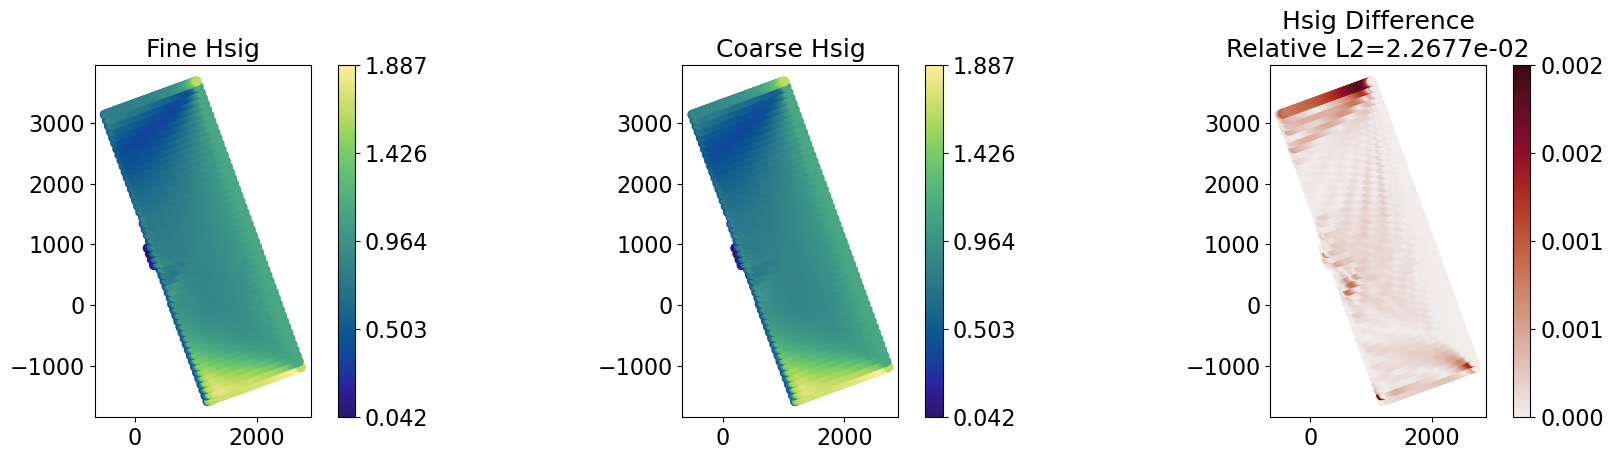

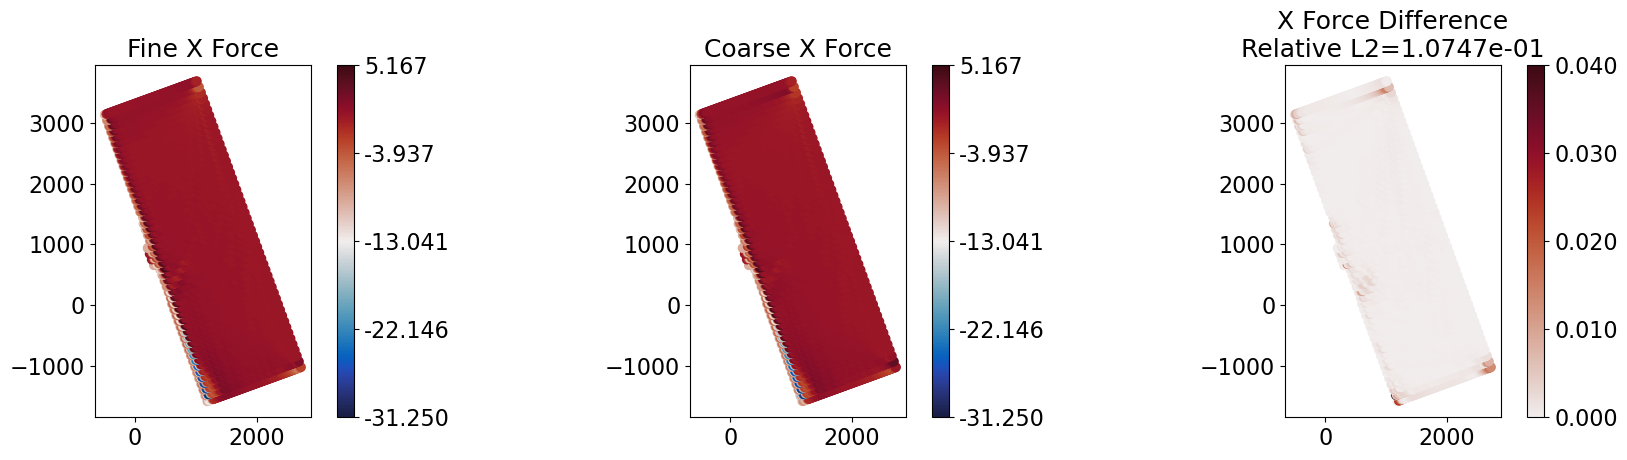

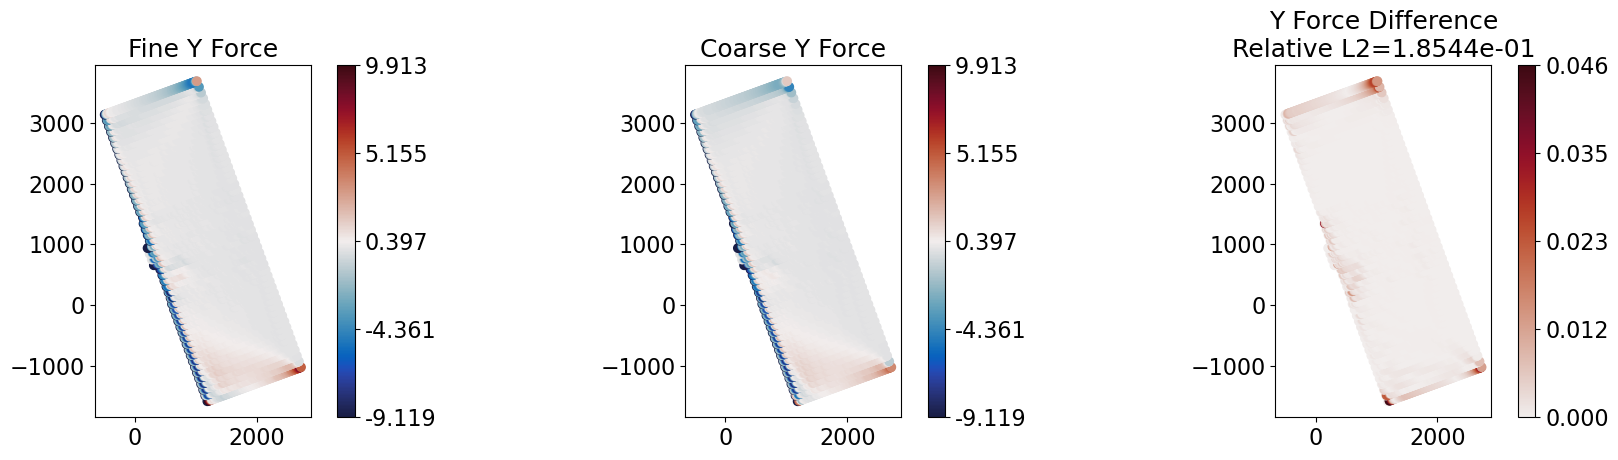

In [36]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(2, 0, 1.6, -20),
    cutoff_value=-60,
    # cutoff_value=None,
    colorbar_mode='data'
    # colorbar_mode='data'
)

Hsig Relative L2 Error : 2.235894e-02
XForce Relative L2 Error: 1.083318e-01
YForce Relative L2 Error: 1.854485e-01


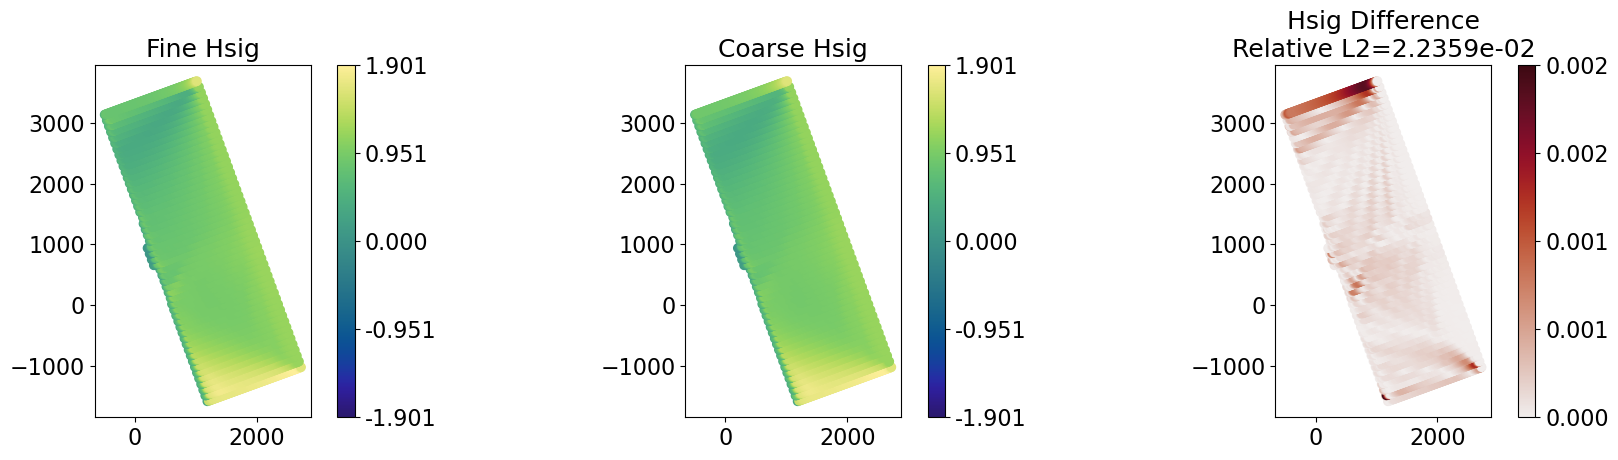

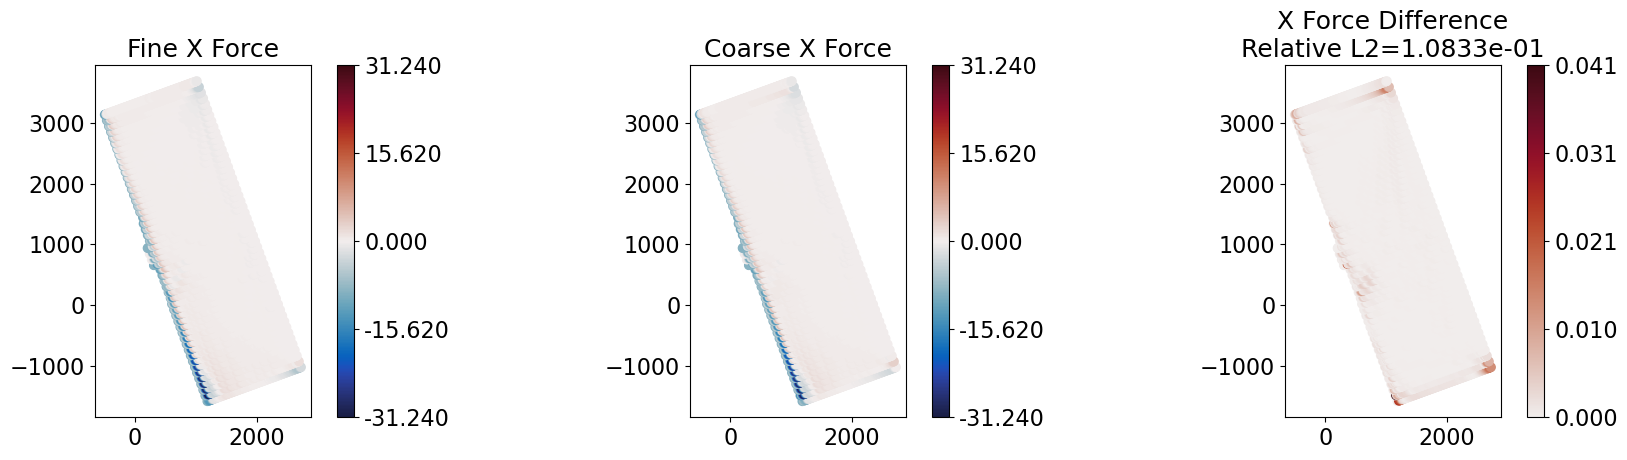

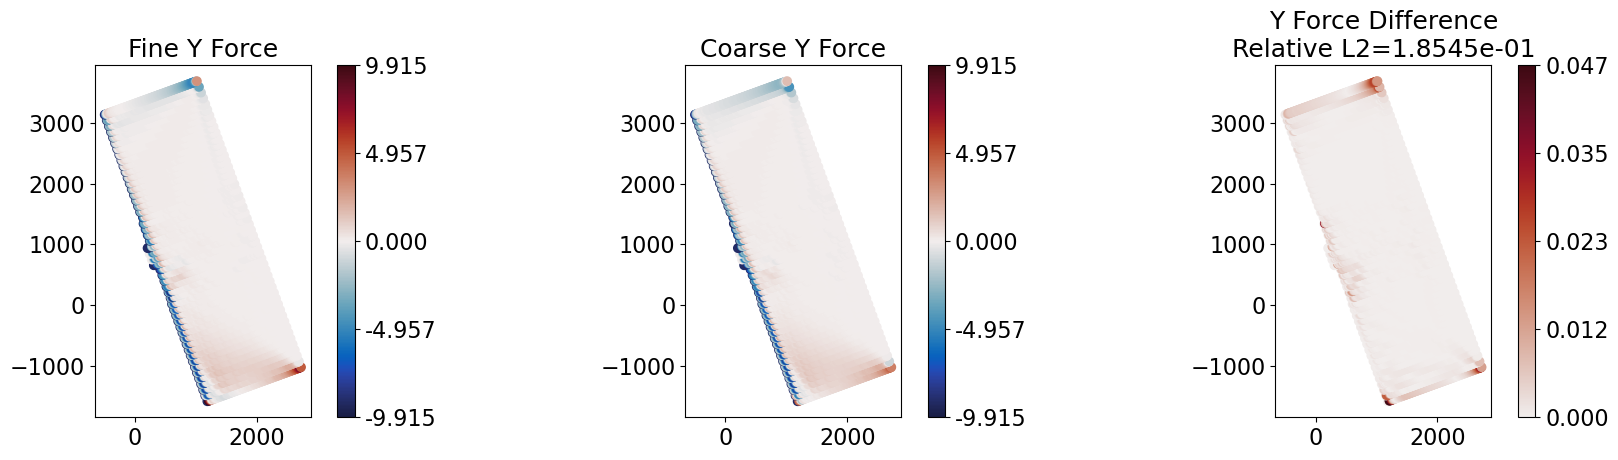

In [37]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(7, 315, 1.6, -20),
    cutoff_value=-60,
    # cutoff_value=-60,
    colorbar_mode='symmetric'
    # colorbar_mode='data'
)

Hsig Relative L2 Error : 7.918003e-03
XForce Relative L2 Error: 6.352922e-02
YForce Relative L2 Error: 2.910406e-01


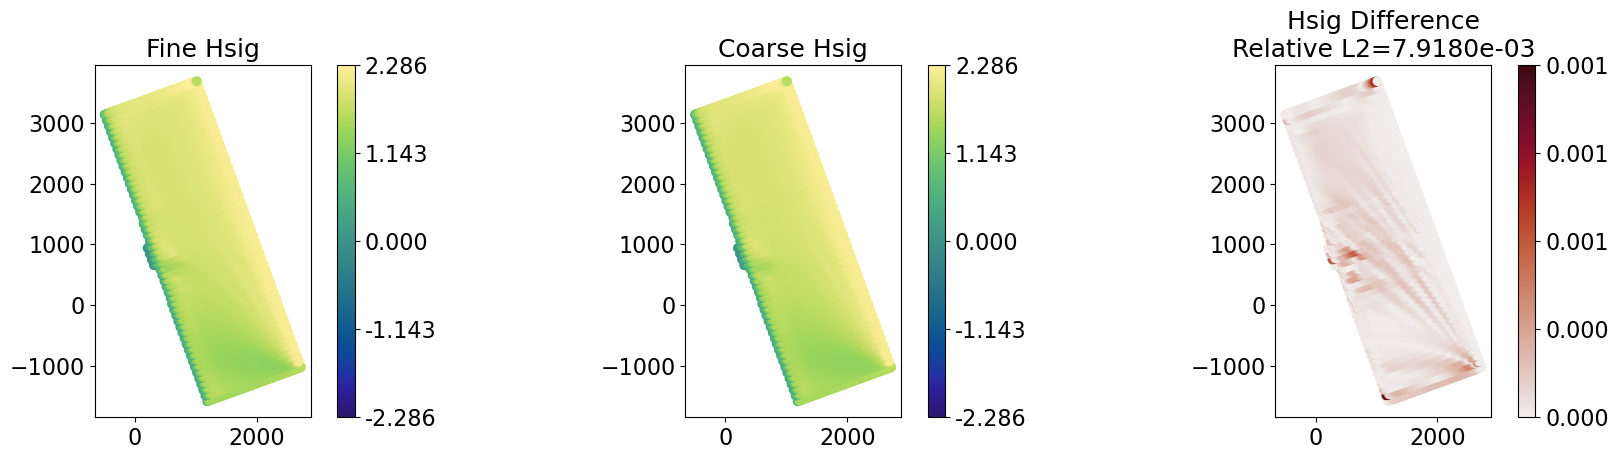

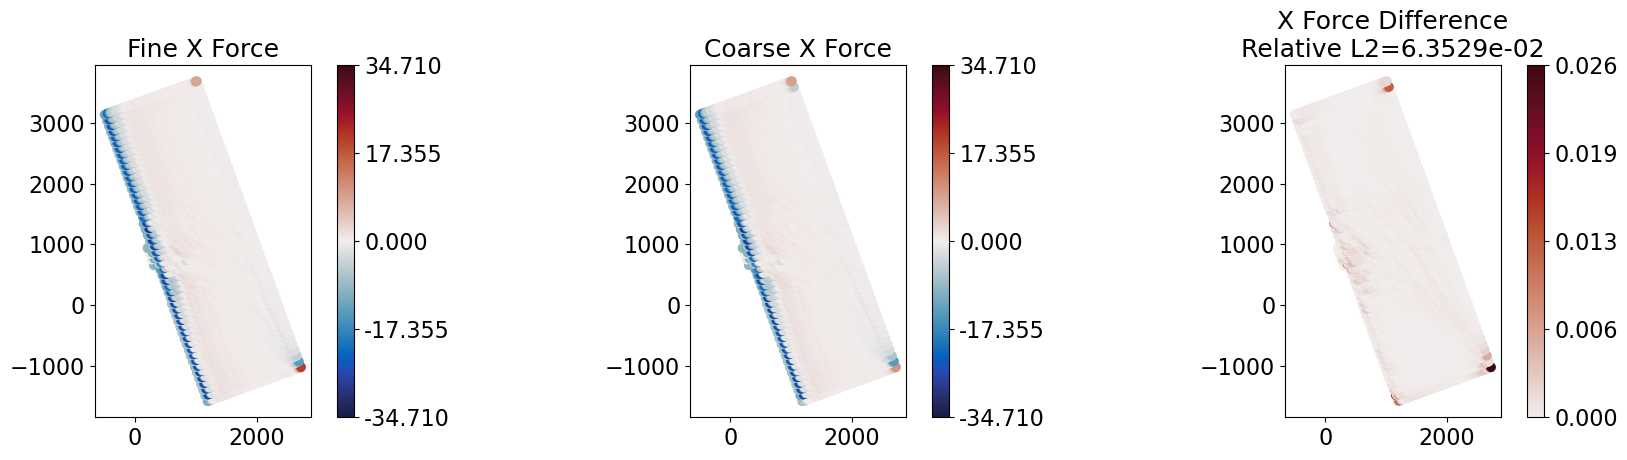

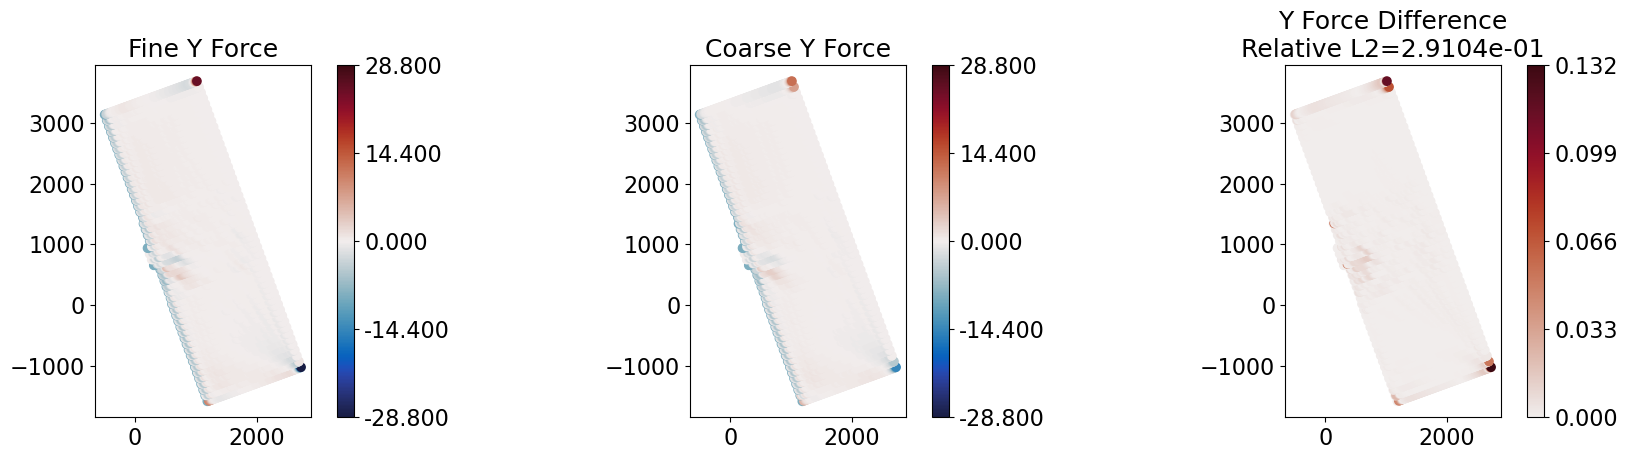

In [38]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(6, 135, 2.6, 140),
    cutoff_value=-60,
    colorbar_mode='symmetric'
)

## Truncated Boundary

### Truncated Mesh Plot

In [39]:
import numpy as np

def build_nonshore_mask(
    vector,
    *,
    shoreline_buffer=2,
    boundary_buffer = 2,
    top_buffer=2,
    bottom_buffer = 2,
):

    marked_indices = []

    for i in range(len(vector) - 1):

        if vector[i + 1] < vector[i]:
            marked_indices.append(i)

    marked_indices.append(len(vector) - 1)

    
    excluded_indices = []

    start_idx = 0
    total_segments = len(marked_indices)

   
    for idx, next_marked_idx in enumerate(marked_indices):

        row_segment = np.arange(
            start_idx,
            next_marked_idx + 1
        )

      
        if (
            idx < bottom_buffer
            or
            idx >= (total_segments - top_buffer)
        ):

            excluded_indices.extend(row_segment)

        else:

      
            shoreline_points = np.concatenate([
                row_segment[:shoreline_buffer],
                row_segment[-boundary_buffer:]
            ])

            excluded_indices.extend(shoreline_points)

      
        start_idx = next_marked_idx + 1

    
    excluded_indices = np.unique(
        np.array(excluded_indices, dtype=np.int64)
    )

    
    nonshore_mask = np.ones(
        len(vector),
        dtype=bool
    )

    nonshore_mask[excluded_indices] = False

    return (
        nonshore_mask,
        excluded_indices,
        marked_indices
    )

In [40]:
validArea_mask, excluded_indices, marked_indices = (
    build_nonshore_mask(
        yp_vector,
        shoreline_buffer=4,
        boundary_buffer = 1,
        top_buffer=5,
        bottom_buffer = 6,
    )
)

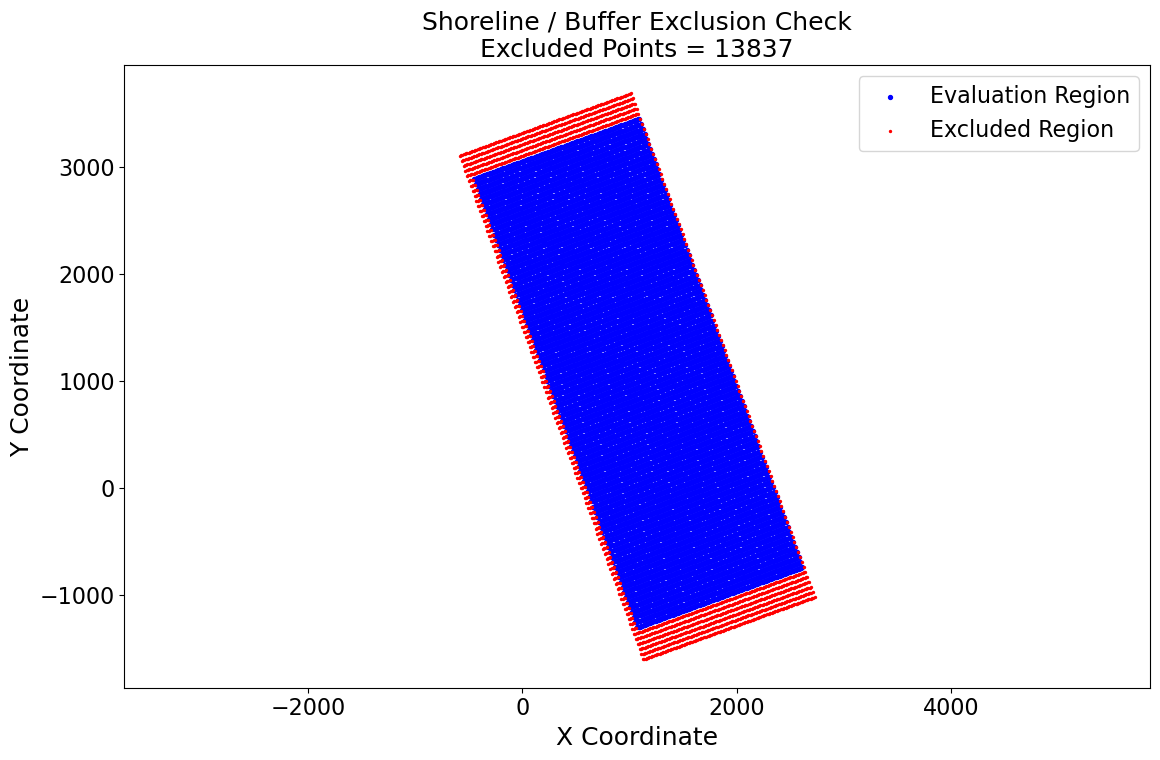

In [41]:
import matplotlib.pyplot as plt
import numpy as np


all_x = xp_vector
all_y = yp_vector

excluded_x = xp_vector[excluded_indices]
excluded_y = yp_vector[excluded_indices]

valid_x = xp_vector[validArea_mask]
valid_y = yp_vector[validArea_mask]


plt.figure(figsize=(12, 8))


# plt.scatter(
#     all_x,
#     all_y,
#     c='lightgray',
#     s=5,
#     label='All Points'
# )

plt.scatter(
    valid_x,
    valid_y,
    c='blue',
    s=8,
    label='Evaluation Region'
)

plt.scatter(
    excluded_x,
    excluded_y,
    c='red',
    s=2,
    label='Excluded Region'
)

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.title(
    f"Shoreline / Buffer Exclusion Check\n"
    f"Excluded Points = {len(validArea_mask)}"
)

plt.legend()

plt.axis('equal')
# plt.savefig('shoreline.pdf')
plt.tight_layout()

plt.show()

In [42]:
new_df = df_fine.copy()

new_df['Hsig Data'] = new_df['Hsig Data'].apply(
    lambda arr: np.array(arr)[validArea_mask]
)

new_df['Forces Data'] = new_df['Forces Data'].apply(
    lambda arr: np.array(arr)[validArea_mask]
)

new_xp_vector = xp_vector[validArea_mask]
new_yp_vector = yp_vector[validArea_mask]

print("Original nodes :", len(xp_vector))
print("Filtered nodes :", len(new_xp_vector))

Original nodes : 13837
Filtered nodes : 11880


In [43]:
fine_coords = np.column_stack(
    (
        new_xp_vector.flatten(),
        new_yp_vector.flatten()
    )
)

coarse_coords = np.column_stack(
    (
        xp_vector_train.flatten(),
        yp_vector_train.flatten()
    )
)

df_fine_spatial = pd.DataFrame(
    fine_coords,
    columns=['x', 'y']
)

df_fine_spatial['fine_index'] = df_fine_spatial.index

df_fine_spatial = df_fine_spatial.set_index(
    ['x', 'y']
)

exact_fine_row_indices = []
exact_coarse_row_indices = []

for coarse_idx, coarse_pt in enumerate(coarse_coords):

    coordinate_tuple = (
        coarse_pt[0],
        coarse_pt[1]
    )

    if coordinate_tuple in df_fine_spatial.index:

        fine_idx = df_fine_spatial.loc[
            coordinate_tuple,
            'fine_index'
        ]

        if isinstance(fine_idx, pd.Series):
            fine_idx = fine_idx.iloc[0]

        exact_fine_row_indices.append(
            int(fine_idx)
        )

        exact_coarse_row_indices.append(
            coarse_idx
        )

exact_fine_row_indices = np.array(
    exact_fine_row_indices,
    dtype=np.int64
)

exact_coarse_row_indices = np.array(
    exact_coarse_row_indices,
    dtype=np.int64
)

print("Matched Fine Nodes  :", len(exact_fine_row_indices))
print("Matched Coarse Nodes:", len(exact_coarse_row_indices))

Matched Fine Nodes  : 5940
Matched Coarse Nodes: 5940


In [44]:

hsig_rel_l2_list = []
xforce_rel_l2_list = []
yforce_rel_l2_list = []

scenario_keys_list = []

for _, row_fine in new_df.iterrows():

    target_key = row_fine['key']

    row_coarse = df_coarse[
        df_coarse['key'] == target_key
    ].iloc[0]

    fine_hsig_full = np.array(
        row_fine['Hsig Data']
    )

    fine_forces_full = np.array(
        row_fine['Forces Data']
    )


    coarse_hsig_full = np.array(
        row_coarse['Hsig Data']
    )

    coarse_forces_full = np.array(
        row_coarse['Forces Data']
    )

    eval_fine_hsig = fine_hsig_full[
        exact_fine_row_indices
    ]

    eval_coarse_hsig = coarse_hsig_full[
        exact_coarse_row_indices
    ]

    fine_forces_matched = fine_forces_full[
        exact_fine_row_indices
    ]

    coarse_forces_matched = coarse_forces_full[
        exact_coarse_row_indices
    ]

    eval_fine_xf = fine_forces_matched[:, 0]
    eval_fine_yf = fine_forces_matched[:, 1]

    eval_coarse_xf = coarse_forces_matched[:, 0]
    eval_coarse_yf = coarse_forces_matched[:, 1]

    strict_water_mask = (
        (eval_fine_hsig != -9.0)
        &
        (eval_coarse_hsig != -9.0)
    )

    eval_fine_hsig = eval_fine_hsig[
        strict_water_mask
    ]

    eval_coarse_hsig = eval_coarse_hsig[
        strict_water_mask
    ]

    eval_fine_xf = eval_fine_xf[
        strict_water_mask
    ]

    eval_coarse_xf = eval_coarse_xf[
        strict_water_mask
    ]

    eval_fine_yf = eval_fine_yf[
        strict_water_mask
    ]

    eval_coarse_yf = eval_coarse_yf[
        strict_water_mask
    ]

    l2_diff_hsig = np.linalg.norm(
        eval_fine_hsig -
        eval_coarse_hsig
    )

    l2_truth_hsig = np.linalg.norm(
        eval_fine_hsig
    )

    hsig_rel_l2 = (
        l2_diff_hsig /
        l2_truth_hsig * 100
    ) if l2_truth_hsig > 1e-9 else 0.0

    hsig_rel_l2_list.append(
        hsig_rel_l2
    )

    l2_diff_xf = np.linalg.norm(
        eval_fine_xf -
        eval_coarse_xf
    )

    l2_truth_xf = np.linalg.norm(
        eval_fine_xf
    )

    xf_rel_l2 = (
        l2_diff_xf /
        l2_truth_xf * 100
    ) if l2_truth_xf > 1e-9 else 0.0

    xforce_rel_l2_list.append(
        xf_rel_l2
    )

    l2_diff_yf = np.linalg.norm(
        eval_fine_yf -
        eval_coarse_yf
    )

    l2_truth_yf = np.linalg.norm(
        eval_fine_yf
    )

    yf_rel_l2 = (
        l2_diff_yf /
        l2_truth_yf * 100
    ) if l2_truth_yf > 1e-9 else 0.0

    yforce_rel_l2_list.append(
        yf_rel_l2
    )

    scenario_keys_list.append(
        target_key
    )

In [45]:
hsig_arr = np.array(
    hsig_rel_l2_list
)

xf_arr = np.array(
    xforce_rel_l2_list
)

yf_arr = np.array(
    yforce_rel_l2_list
)

print("\n=======================================================")
print("     FILTERED COARSE VS FINE COMPARISON")
print("=======================================================")

print(
    f"Mean Hsig Relative L2 Error: "
    f"{np.mean(hsig_arr):.2f}%"
)

print(
    f"Median Hsig Relative L2 Error: "
    f"{np.median(hsig_arr):.2f}%"
)

print("-------------------------------------------------------")

print(
    f"Mean XForce Relative L2 Error: "
    f"{np.mean(xf_arr):.2f}%"
)

print(
    f"Median XForce Relative L2 Error: "
    f"{np.median(xf_arr):.2f}%"
)

print("-------------------------------------------------------")

print(
    f"Mean YForce Relative L2 Error: "
    f"{np.mean(yf_arr):.2f}%"
)

print(
    f"Median YForce Relative L2 Error: "
    f"{np.median(yf_arr):.2f}%"
)

print("=======================================================")


     FILTERED COARSE VS FINE COMPARISON
Mean Hsig Relative L2 Error: 0.61%
Median Hsig Relative L2 Error: 0.48%
-------------------------------------------------------
Mean XForce Relative L2 Error: 4.25%
Median XForce Relative L2 Error: 4.11%
-------------------------------------------------------
Mean YForce Relative L2 Error: 10.17%
Median YForce Relative L2 Error: 9.04%


In [46]:
worst_hsig_idx = np.argmax(hsig_arr)
worst_xf_idx = np.argmax(xf_arr)
worst_yf_idx = np.argmax(yf_arr)

worst_hsig_key = scenario_keys_list[worst_hsig_idx]
worst_xf_key = scenario_keys_list[worst_xf_idx]
worst_yf_key = scenario_keys_list[worst_yf_idx]


# =================================================================
# GENERATE SUMMARY DISCREPANCY BENCHMARK REPORT
# =================================================================
print("\n=======================================================")
print("     COARSE VS FINE DIRECT NODE METRICS SUMMARY        ")
print("=======================================================")
print(f"Total Scenarios Compared:       {len(scenario_keys_list)}")
print("-------------------------------------------------------")
print(f"Worst Hsig Scenario Key:        {worst_hsig_key} ({hsig_arr[worst_hsig_idx]:.2f}%)")
print("-------------------------------------------------------")
print(f"Worst X-Force Scenario Key:     {worst_xf_key} ({xf_arr[worst_xf_idx]:.2f}%)")
print("-------------------------------------------------------")
print(f"Worst Y-Force Scenario Key:     {worst_yf_key} ({yf_arr[worst_yf_idx]:.2f}%)")
print("=======================================================")


     COARSE VS FINE DIRECT NODE METRICS SUMMARY        
Total Scenarios Compared:       576
-------------------------------------------------------
Worst Hsig Scenario Key:        (6, 135, 1.6, -20) (1.40%)
-------------------------------------------------------
Worst X-Force Scenario Key:     (2, 90, 1.8, 160) (7.01%)
-------------------------------------------------------
Worst Y-Force Scenario Key:     (6, 135, 2.6, 140) (17.18%)


### Plot Truncated Mesh Scenarios from Coarse and Fine Grids SWAN

In [47]:
fine_grid = GridData(
    name='fine',
    x_vector=xp_vector,
    y_vector=yp_vector,
    df=df_fine,
    mask=validArea_mask
)

coarse_grid = GridData(
    name='coarse',
    x_vector=xp_vector_train,
    y_vector=yp_vector_train,
    df=test_df_train
)

overlap_info = build_overlap(
    coarse_grid,
    fine_grid
)

Hsig Relative L2 Error : 1.317683e-02
XForce Relative L2 Error: 5.278922e-02
YForce Relative L2 Error: 8.015945e-02


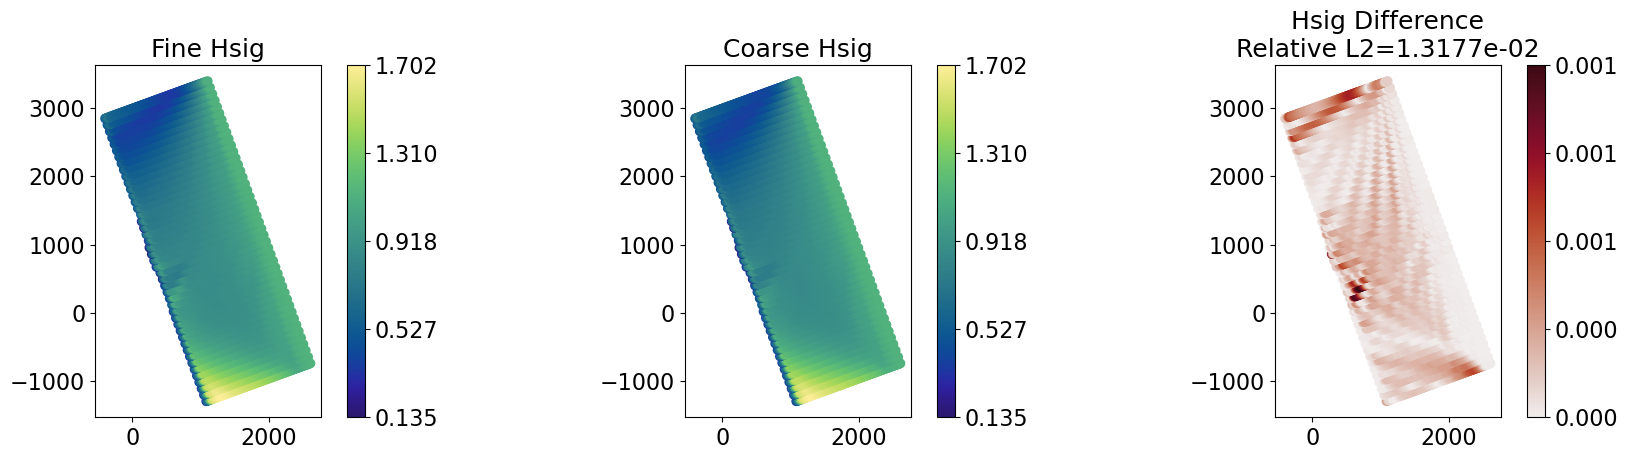

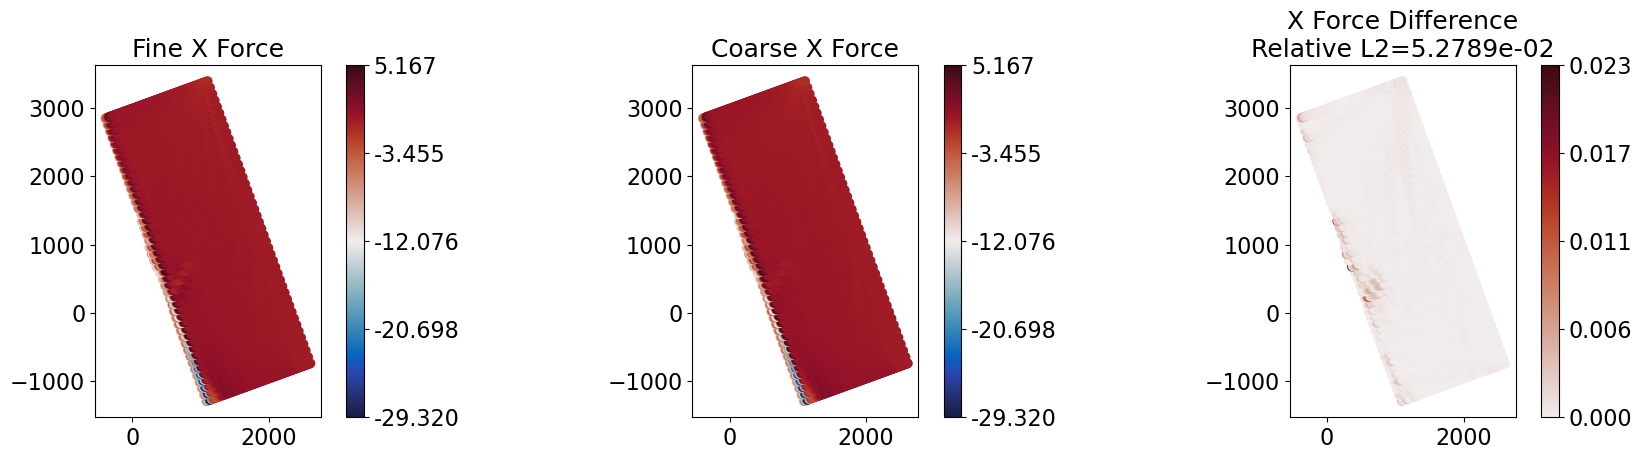

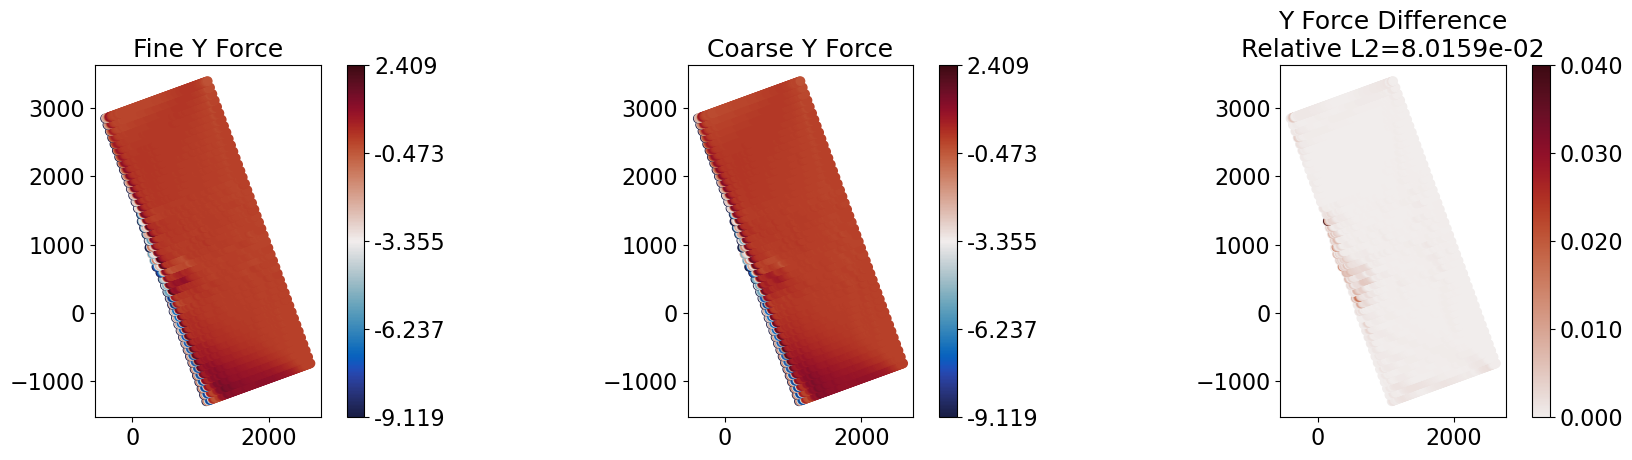

In [49]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(2, 0, 1.6, -20),
    colorbar_mode='data'
)

Hsig Relative L2 Error : 1.312618e-02
XForce Relative L2 Error: 5.383749e-02
YForce Relative L2 Error: 8.029469e-02


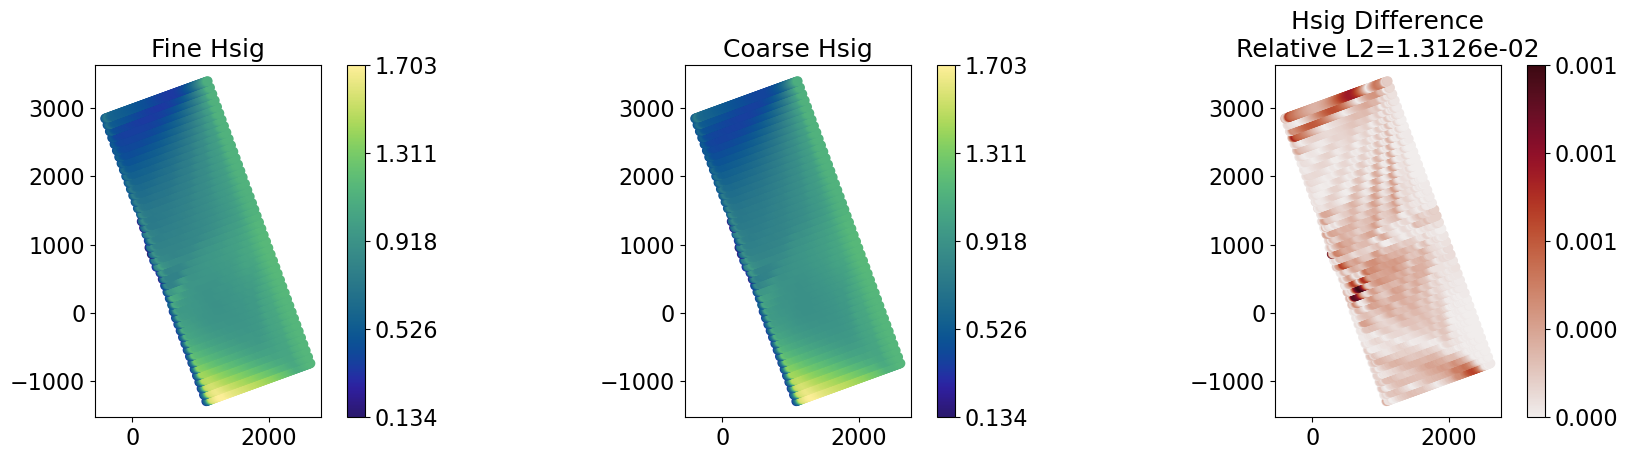

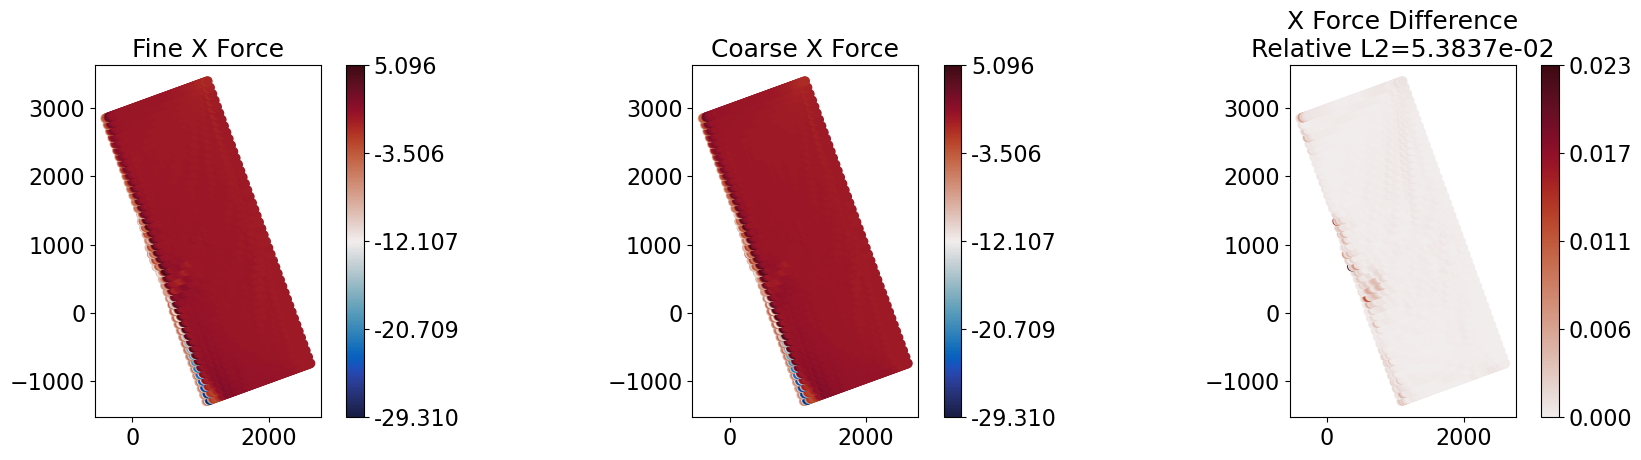

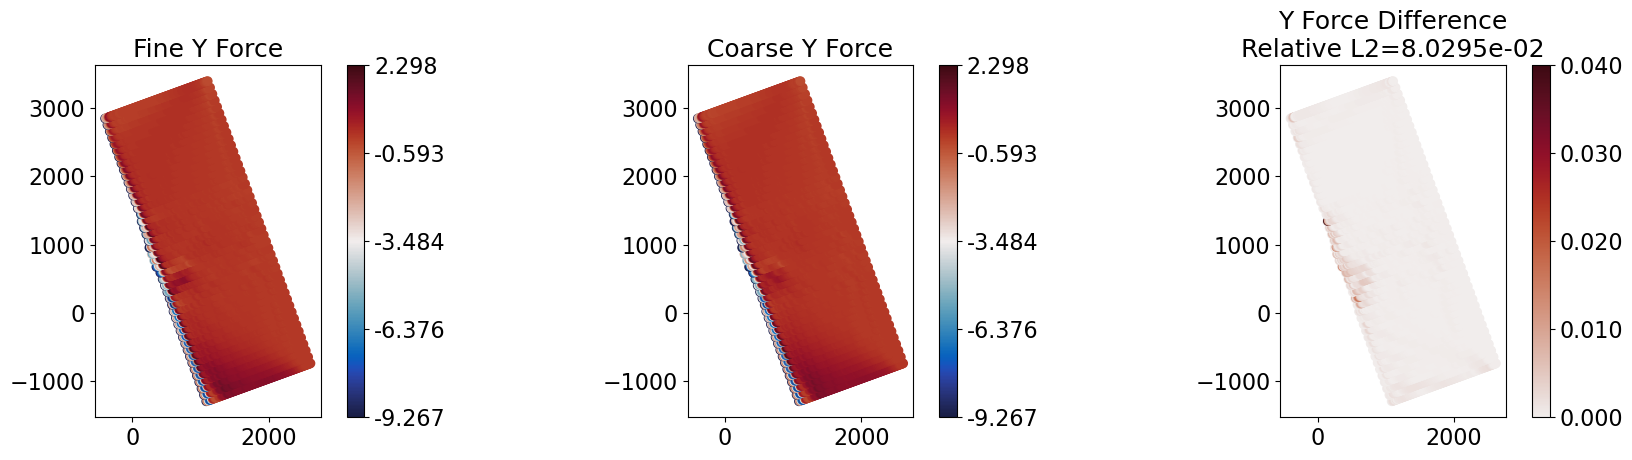

In [48]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(7, 315, 1.6, -20),
     # cutoff_value=-60,
    colorbar_mode='data' ## symmetric
)

Hsig Relative L2 Error : 6.784737e-03
XForce Relative L2 Error: 4.136073e-02
YForce Relative L2 Error: 1.717873e-01


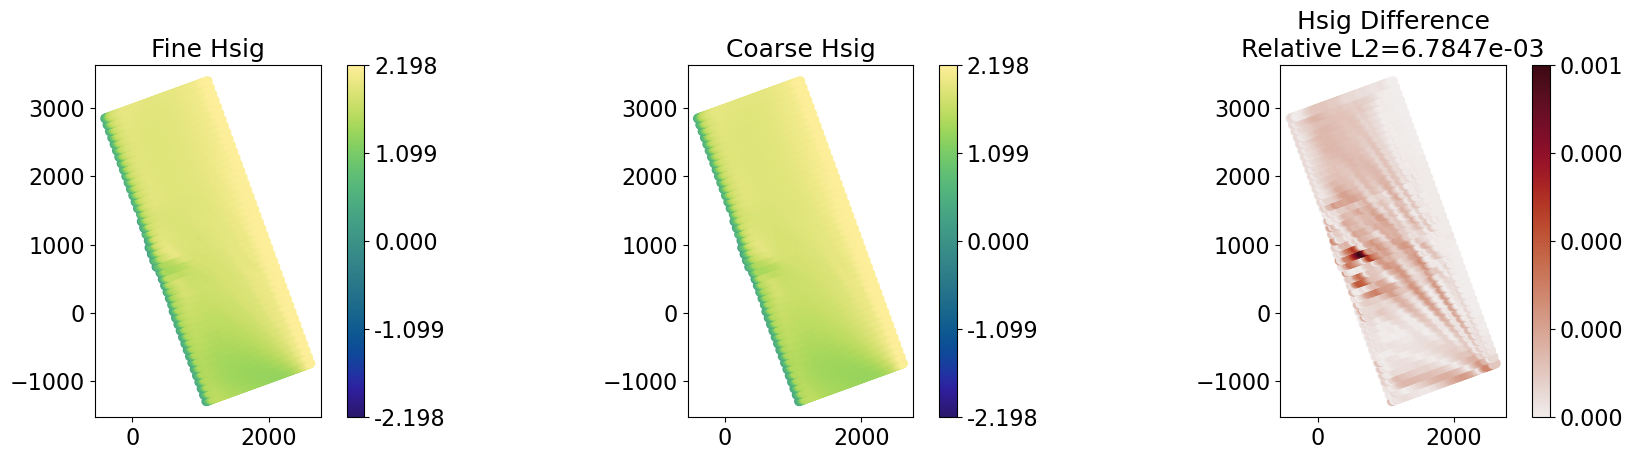

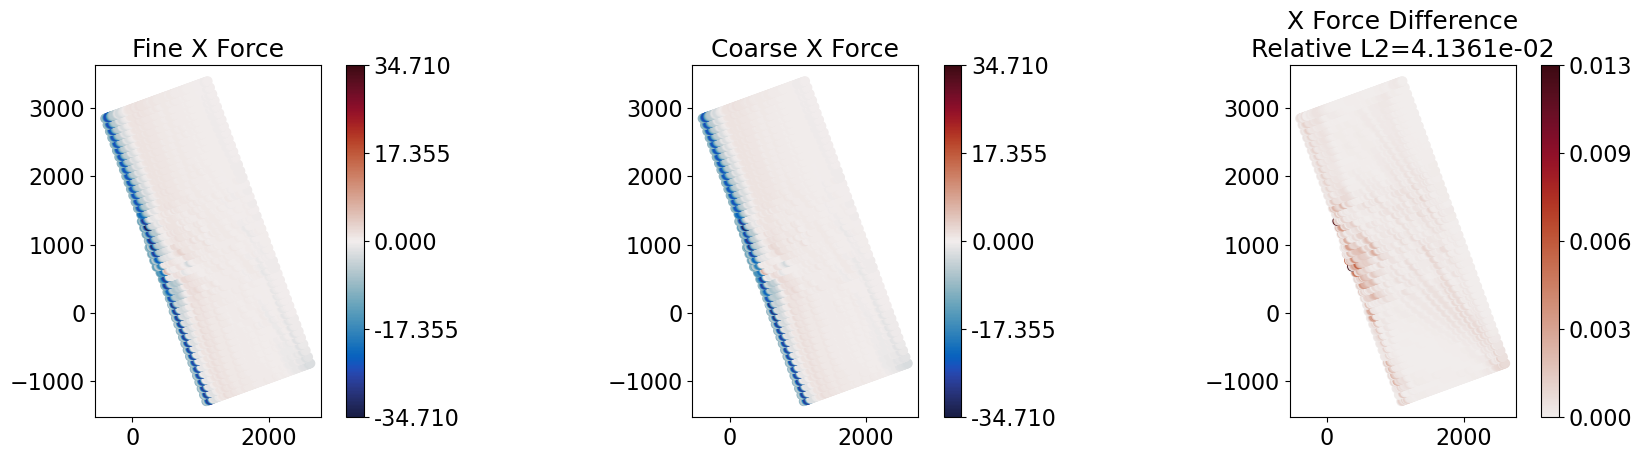

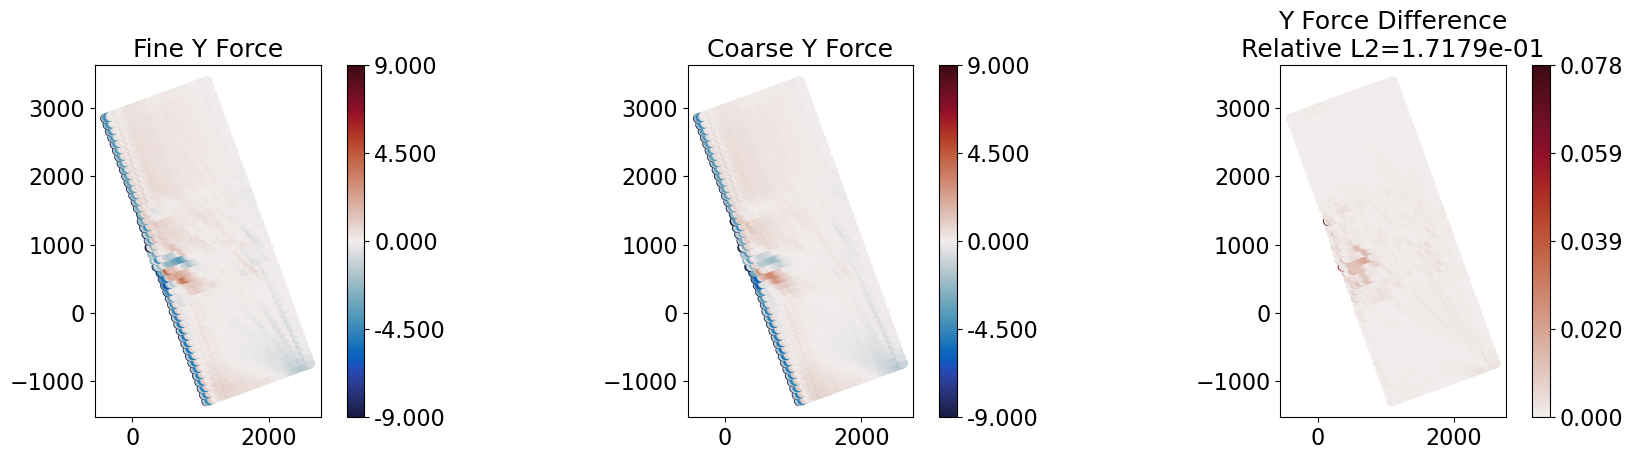

In [50]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(6, 135, 2.6, 140),
    cutoff_value=-60,
    colorbar_mode='symmetric'
)

# DON Prediction

## Plot Functions

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean

from matplotlib.ticker import FormatStrFormatter


def plot_prediction_comparison(
    true_vec,
    pred_vec,
    xp_vector,
    yp_vector,
    valid_mask,
    valid_area_mask=None,
    title_prefix='Field',
    pointwise_mode='normalized_l2',
    point_size=8,
    cutoff_value=None,
    cutoff_tol=1e-6,
    colorbar_mode='data',
    # 'data'
    # 'symmetric'
    # 'manual'

    physics_vmin=None,
    physics_vmax=None,
    vmax_error=None,
    err_cbar_max=None,   # percentile (e.g. 99) to clip the error colorbar; None -> true max
    num_ticks=5,
    save_path=None,
):


    valid = valid_mask.copy()

    if valid_area_mask is not None:

        valid = valid & valid_area_mask

    if cutoff_value is not None:

        cutoff_mask = (
            np.abs(true_vec - cutoff_value) > cutoff_tol
        ) & (
            np.abs(pred_vec - cutoff_value) > cutoff_tol
        )

        valid = valid & cutoff_mask

    diff = pred_vec - true_vec

    abs_diff = np.abs(diff)


    domain_l2 = np.linalg.norm(
        true_vec[valid], ord = 2
    )

    if domain_l2 < 1e-12:

        global_relative_l2 = 0.0

    else:

        global_relative_l2 = (
            np.linalg.norm(diff[valid], ord = 2)
            / domain_l2
        )


    if pointwise_mode == 'normalized_l2':

        if domain_l2 < 1e-12:

            error_field = np.zeros_like(diff)

        else:

            # error_field = (
            #     diff**2
            #     / domain_l2**2
            # )
            error_field = (
                abs_diff
                / domain_l2
            )

        error_title = (
            'Pointwise Normalized L2 Contribution'

        
        )

    elif pointwise_mode == 'absolute':

        error_field = abs_diff

        error_title = 'Absolute Error'

    elif pointwise_mode == 'relative':

        eps = 1e-12

        error_field = (
            abs_diff
            /
            (np.abs(true_vec) + eps)
        )

        error_title = 'Pointwise Relative Error'

    else:

        raise ValueError(
            f'Unknown pointwise_mode: {pointwise_mode}'
        )



    if title_prefix.lower() == 'hsig':

        physics_cmap = cmocean.cm.haline.copy()

    else:

        physics_cmap = cmocean.cm.balance.copy()

    error_cmap = cmocean.cm.amp.copy()


    if (
        physics_vmin is not None
        and
        physics_vmax is not None
    ):

        vmin = physics_vmin
        vmax = physics_vmax

    elif colorbar_mode == 'symmetric':

        vmax_abs = max(
            np.nanmax(np.abs(true_vec[valid])),
            np.nanmax(np.abs(pred_vec[valid]))
        )

        vmin = -vmax_abs
        vmax = vmax_abs

    elif colorbar_mode == 'data':

        vmin = min(
            np.nanmin(true_vec[valid]),
            np.nanmin(pred_vec[valid])
        )

        vmax = max(
            np.nanmax(true_vec[valid]),
            np.nanmax(pred_vec[valid])
        )

    else:

        raise ValueError(
            f'Unknown colorbar_mode: {colorbar_mode}'
        )


    if vmax_error is not None:

        diff_vmax = vmax_error

    elif err_cbar_max is not None:

        diff_vmax = float(
            np.nanpercentile(
                error_field[valid],
                err_cbar_max
            )
        )

    else:

        diff_vmax = np.nanmax(
            error_field[valid]
        )

    diff_vmin = 0


    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5)
    )


    sc1 = axes[0].scatter(
        xp_vector[valid],
        yp_vector[valid],

        c=true_vec[valid],

        cmap=physics_cmap,

        s=point_size,

        vmin=vmin,
        vmax=vmax
    )

    axes[0].set_title(
        f'{title_prefix} TRUE'
    )

    axes[0].set_aspect('equal')

    cbar1 = plt.colorbar(
        sc1,
        ax=axes[0]
    )

    ticks1 = np.linspace(
        vmin,
        vmax,
        num_ticks
    )

    cbar1.set_ticks(ticks1)

    cbar1.ax.yaxis.set_major_formatter(
        FormatStrFormatter('%.3f')
    )


    sc2 = axes[1].scatter(
        xp_vector[valid],
        yp_vector[valid],

        c=pred_vec[valid],

        cmap=physics_cmap,

        s=point_size,

        vmin=vmin,
        vmax=vmax
    )

    axes[1].set_title(
        f'{title_prefix} PREDICT'
    )

    axes[1].set_aspect('equal')

    cbar2 = plt.colorbar(
        sc2,
        ax=axes[1]
    )

    ticks2 = np.linspace(
        vmin,
        vmax,
        num_ticks
    )

    cbar2.set_ticks(ticks2)

    cbar2.ax.yaxis.set_major_formatter(
        FormatStrFormatter('%.3f')
    )


    sc3 = axes[2].scatter(
        xp_vector[valid],
        yp_vector[valid],

        c=error_field[valid],

        cmap=error_cmap,

        s=point_size,

        vmin=diff_vmin,
        vmax=diff_vmax
    )

    axes[2].set_title(
        f'{error_title}\n'
        f'Global Relative L2 = '
        f'{global_relative_l2:.4e}'
    )

    axes[2].set_aspect('equal')

    cbar3 = plt.colorbar(
        sc3,
        ax=axes[2]
    )

    ticks3 = np.linspace(
        diff_vmin,
        diff_vmax,
        num_ticks
    )

    cbar3.set_ticks(ticks3)

    cbar3.ax.yaxis.set_major_formatter(
        FormatStrFormatter('%.6f')
    )

    for ax in axes:
    
        ax.set_aspect(
            'equal',
            adjustable='box'
        )

    axes[0].set_ylabel('Y Coordinate')

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(
            save_path,
            format='pdf',
            bbox_inches='tight'
        )

    plt.show()



    return {

        'global_relative_l2': global_relative_l2,

        'error_field': error_field,

        'valid_mask': valid,

        'domain_l2': domain_l2,
    }

## Hsig

In [52]:
results_h = ModelAnalysis.compute_metrics_comprehensive(     
    test_df=test_df,
    xp_vector=xp_vector,
    yp_vector=yp_vector,
   model_dir="../Models/model_DUCK_Hsig",
    component="hsig",
    )

2026-09-09 13:45:08.067432: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 866 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:be:00.0, compute capability: 8.9
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://sc

In [53]:
all_true = results_h["all_true_vectors"]
all_pred = results_h["all_pred_vectors"]
all_valid = results_h["all_valid_masks"]
new_rel_l2 = []

for i in range(len(all_true)):

    true_vec = all_true[i]
    pred_vec = all_pred[i]
    valid_mask = all_valid[i]

    mask = np.zeros(len(true_vec), dtype=bool)
    mask[validArea_mask] = True

    final_mask = valid_mask & mask

    diff = pred_vec[final_mask] - true_vec[final_mask]

    l2_diff = np.linalg.norm(diff)
    l2_true = np.linalg.norm(true_vec[final_mask])

    rel_l2 = l2_diff / l2_true

    new_rel_l2.append(rel_l2)

In [83]:
# data = new_rel_l2
# mean_val = np.mean(data)
# median_val = np.median(data)

# # 2. Plotting
# plt.figure(figsize=(10, 6))
# plt.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# plt.title("Hsig Model: Distribution of Relative $L_2$ Error", fontsize=14, fontweight='bold')
# plt.xlabel("Relative $L_2$ Error", fontsize=12)
# plt.ylabel("Number of Scenarios", fontsize=12)
# plt.grid(axis='y', alpha=0.3)
# plt.legend(loc='upper right')

# # Optional: Set x-axis limit if you want to focus on the bulk of data (0-30%)
# # plt.xlim(0, 30)

# plt.tight_layout()
# plt.savefig("./Results/HsigModel_Distribution_RelativeL2Error.pdf")
# plt.show()

In [54]:
# 1. Convert to array and handle NaNs (if any)
arr = np.asarray(new_rel_l2)
valid_mask = np.isfinite(arr)

# 2. Get indices that sort the array in ascending order (Best to Worst)
sorted_indices = np.where(valid_mask)[0]
sorted_indices = sorted_indices[np.argsort(arr[valid_mask])]

# 3. Identify the Best 3 (lowest relative error)
best_3_indices = sorted_indices[:3]

# 4. Identify the Worst 3 (highest relative error)
# We take the last 3 and reverse them so the absolute worst is first
worst_3_indices = sorted_indices[-3:][::-1]

# # --- Display Results ---

print("--- TOP 3 BEST SCENARIOS (Lowest L2 Error) ---")
for i, idx in enumerate(best_3_indices, 1):
    print(f"Rank {i}: Index {idx:4d} | Rel L2 Error: {arr[idx]:.2f}")

print("\n--- TOP 3 WORST SCENARIOS (Highest L2 Error) ---")
for i, idx in enumerate(worst_3_indices, 1):
    print(f"Rank {i}: Index {idx:4d} | Rel L2 Error: {arr[idx]:.2f}")

--- TOP 3 BEST SCENARIOS (Lowest L2 Error) ---
Rank 1: Index  261 | Rel L2 Error: 0.01
Rank 2: Index   59 | Rel L2 Error: 0.01
Rank 3: Index  321 | Rel L2 Error: 0.01

--- TOP 3 WORST SCENARIOS (Highest L2 Error) ---
Rank 1: Index  352 | Rel L2 Error: 0.03
Rank 2: Index  510 | Rel L2 Error: 0.03
Rank 3: Index  451 | Rel L2 Error: 0.03


In [55]:
print(np.mean(new_rel_l2))
print(np.max(new_rel_l2))
print(np.median(new_rel_l2))

0.012486146278818187
0.0316802742650548
0.010913395681874969


In [56]:
print(results_h['scenario_keys'][352])

(7, 315, 1.6, -20)


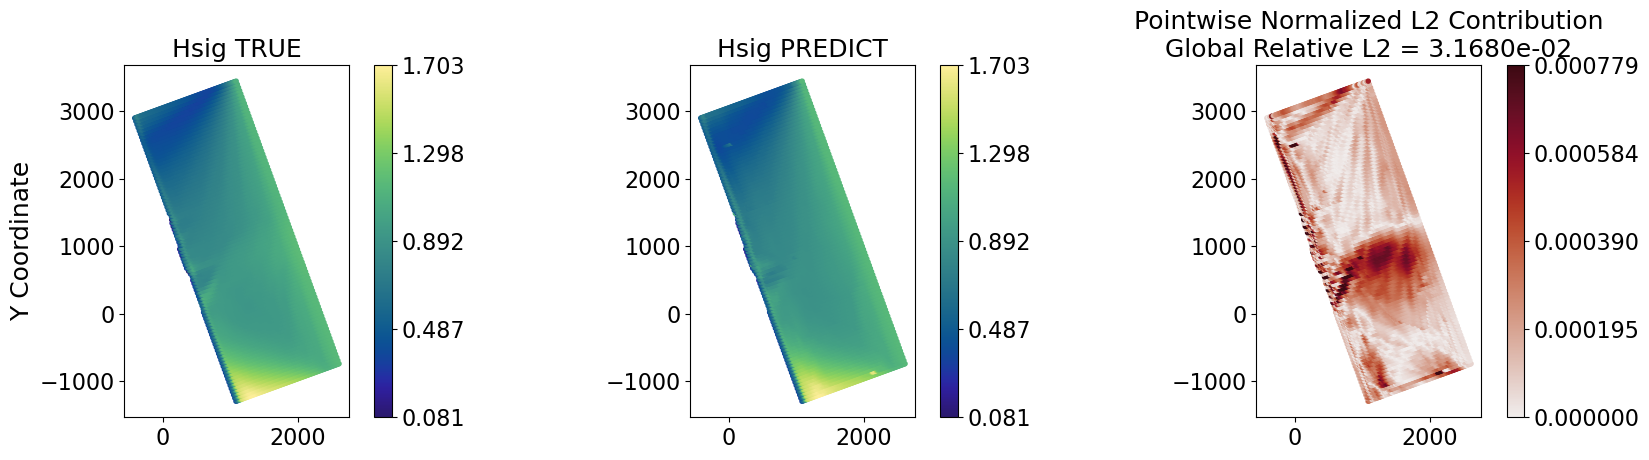

In [57]:
idx = 352


results = plot_prediction_comparison(
    true_vec=all_true[idx],
    pred_vec=all_pred[idx],

    xp_vector=xp_vector,
    yp_vector=yp_vector,

    valid_mask=all_valid[idx],

    valid_area_mask=validArea_mask,

    title_prefix='Hsig',

    pointwise_mode='normalized_l2',

    colorbar_mode='data',

    vmax_error=None,
    err_cbar_max=99,

    cutoff_value=None,


    point_size=8,

    num_ticks=5,
    # save_path = './Results/Hsig_prediction.pdf'
)

Hsig Relative L2 Error : 1.312618e-02
XForce Relative L2 Error: 5.383749e-02
YForce Relative L2 Error: 8.029469e-02


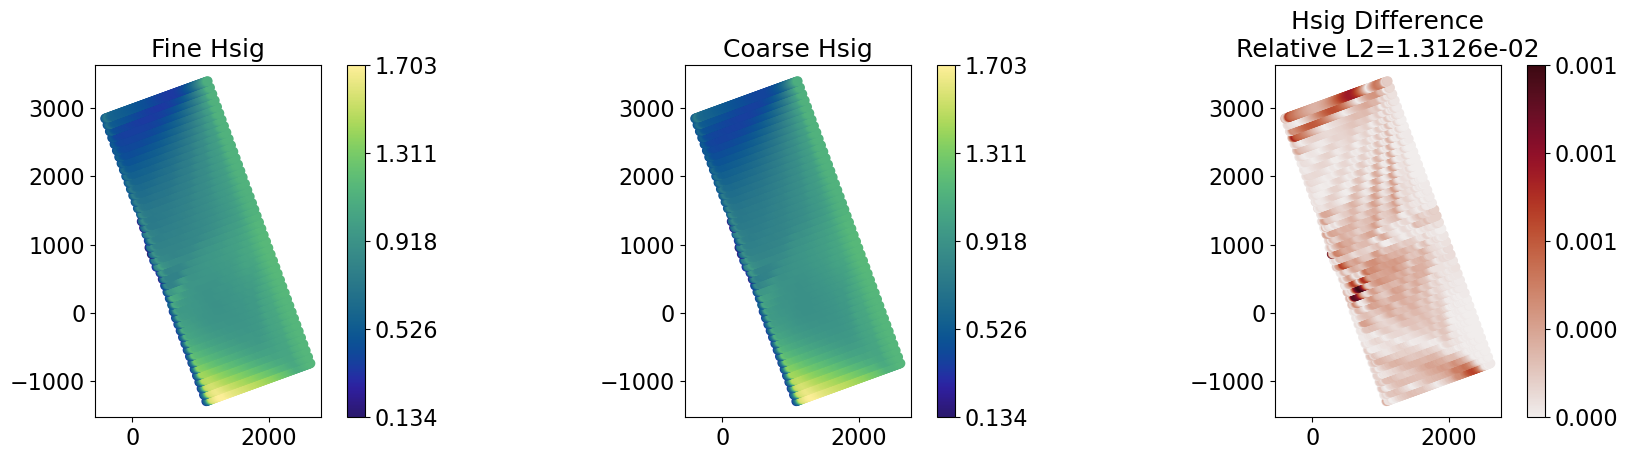

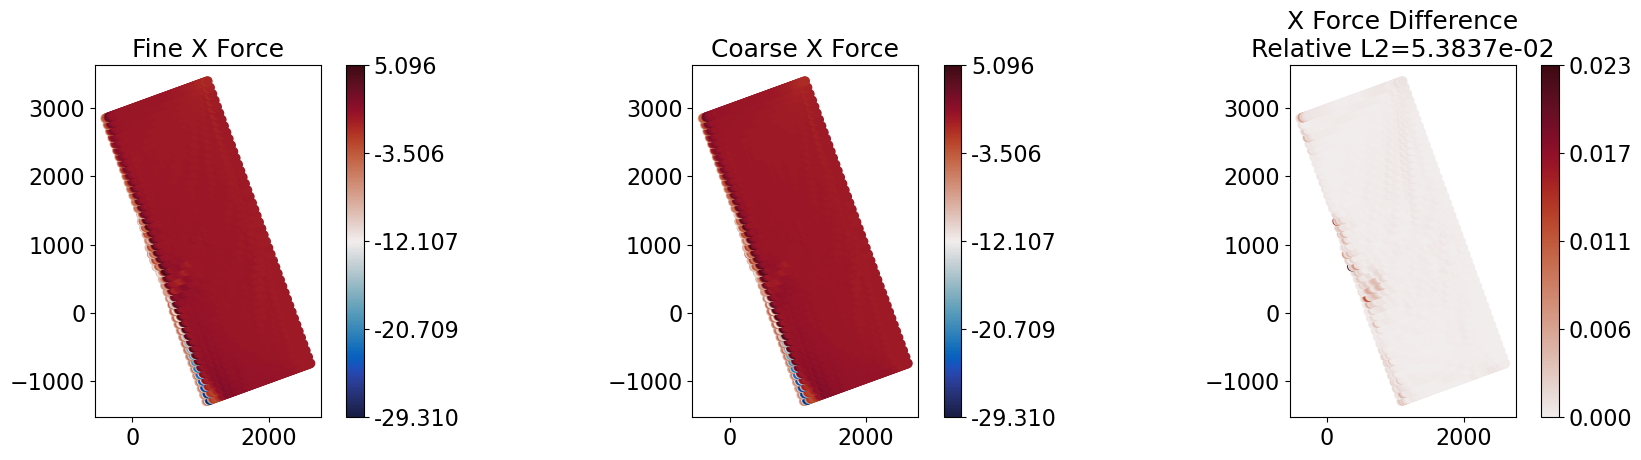

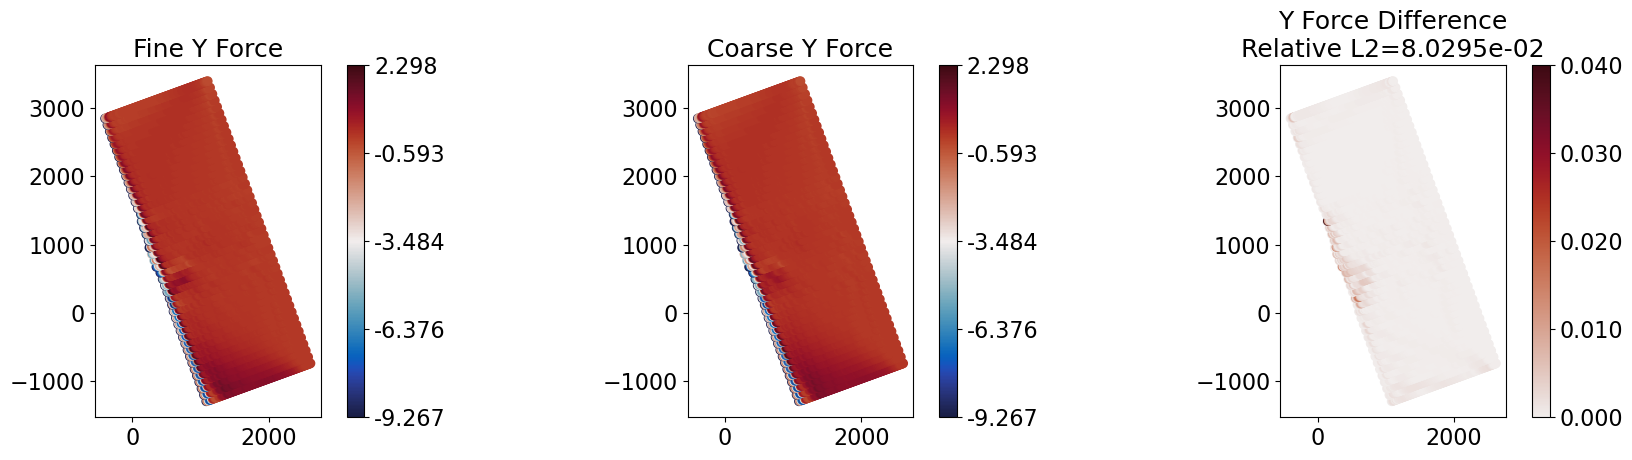

In [90]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(7, 315, 1.6, -20),
    # save_dir="./Results/"
)

## x-Forces

In [91]:
results_x = ModelAnalysis.compute_metrics_comprehensive(     
    test_df=test_df,
    xp_vector=xp_vector,
    yp_vector=yp_vector,
    model_dir="../Models/model_DUCK_xforces",
    component="x",)

/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

In [92]:
all_true = results_x["all_true_vectors"]
all_pred = results_x["all_pred_vectors"]
all_valid = results_x["all_valid_masks"]
new_rel_l2 = []

for i in range(len(all_true)):

    true_vec = all_true[i]
    pred_vec = all_pred[i]
    valid_mask = all_valid[i]

    mask = np.zeros(len(true_vec), dtype=bool)
    mask[validArea_mask] = True

    final_mask = valid_mask & mask

    diff = pred_vec[final_mask] - true_vec[final_mask]

    l2_diff = np.linalg.norm(diff)
    l2_true = np.linalg.norm(true_vec[final_mask])

    rel_l2 = l2_diff / l2_true

    new_rel_l2.append(rel_l2)

In [93]:
# data = new_rel_l2
# mean_val = np.mean(data)
# median_val = np.median(data)

# # 2. Plotting
# plt.figure(figsize=(10, 6))
# plt.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# plt.title("X-Force Model: Distribution of Relative $L_2$ Error", fontsize=14, fontweight='bold')
# plt.xlabel("Relative $L_2$ Error", fontsize=12)
# plt.ylabel("Number of Scenarios", fontsize=12)
# plt.grid(axis='x', alpha=0.3)
# plt.legend(loc='upper right')

# # Optional: Set x-axis limit if you want to focus on the bulk of data (0-30%)
# # plt.xlim(0, 30)

# plt.tight_layout()
# plt.savefig("./Results/X-ForceModel_Distribution_RelativeL2Error.pdf")
# plt.show()

In [97]:
# 1. Convert to array and handle NaNs (if any)
arr = np.asarray(new_rel_l2)
valid_mask = np.isfinite(arr)

# 2. Get indices that sort the array in ascending order (Best to Worst)
sorted_indices = np.where(valid_mask)[0]
sorted_indices = sorted_indices[np.argsort(arr[valid_mask])]

# 3. Identify the Best 3 (lowest relative error)
best_3_indices = sorted_indices[:3]

# 4. Identify the Worst 3 (highest relative error)
# We take the last 3 and reverse them so the absolute worst is first
worst_3_indices = sorted_indices[-3:][::-1]

# # --- Display Results ---

print("--- TOP 3 BEST SCENARIOS (Lowest L2 Error) ---")
for i, idx in enumerate(best_3_indices, 1):
    print(f"Rank {i}: Index {idx:4d} | Rel L2 Error: {arr[idx]:.2f}")

print("\n--- TOP 3 WORST SCENARIOS (Highest L2 Error) ---")
for i, idx in enumerate(worst_3_indices, 1):
    print(f"Rank {i}: Index {idx:4d} | Rel L2 Error: {arr[idx]:.2f}")

--- TOP 3 BEST SCENARIOS (Lowest L2 Error) ---
Rank 1: Index  565 | Rel L2 Error: 0.08
Rank 2: Index  163 | Rel L2 Error: 0.08
Rank 3: Index   66 | Rel L2 Error: 0.08

--- TOP 3 WORST SCENARIOS (Highest L2 Error) ---
Rank 1: Index  397 | Rel L2 Error: 0.15
Rank 2: Index  392 | Rel L2 Error: 0.14
Rank 3: Index  164 | Rel L2 Error: 0.14


In [95]:
print(np.mean(new_rel_l2))
print(np.max(new_rel_l2))
print(np.median(new_rel_l2))

0.09133401268034023
0.14845984938314494
0.08669671596793137


In [96]:
print(results_x['scenario_keys'][397])

(8, 0, 1.6, 160)


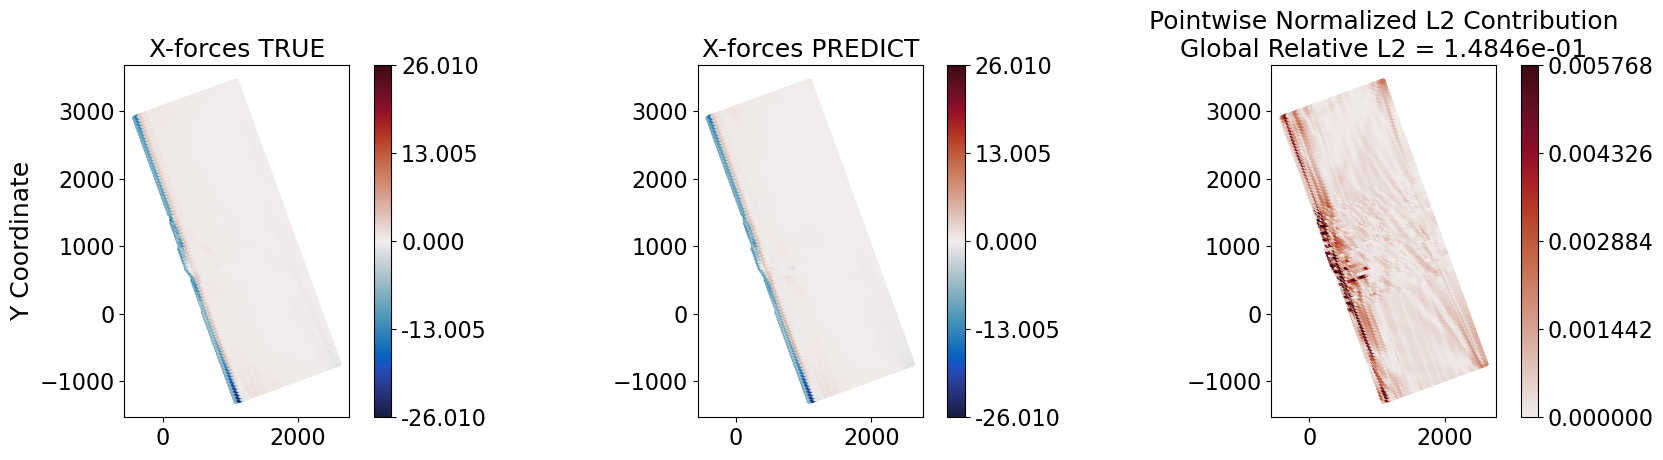

In [98]:
idex = 397
results = plot_prediction_comparison(

    true_vec=all_true[idex],
    pred_vec=all_pred[idex],

    xp_vector=xp_vector,
    yp_vector=yp_vector,

    valid_mask=all_valid[idex],

    valid_area_mask=validArea_mask,

    title_prefix='X-forces',

    pointwise_mode='normalized_l2',

    colorbar_mode='symmetric',

    vmax_error=None,
    err_cbar_max=99,

    cutoff_value=None,


    point_size=8,

    num_ticks=5,
    # save_path = './Results/Xforces_prediction.pdf'
    
)

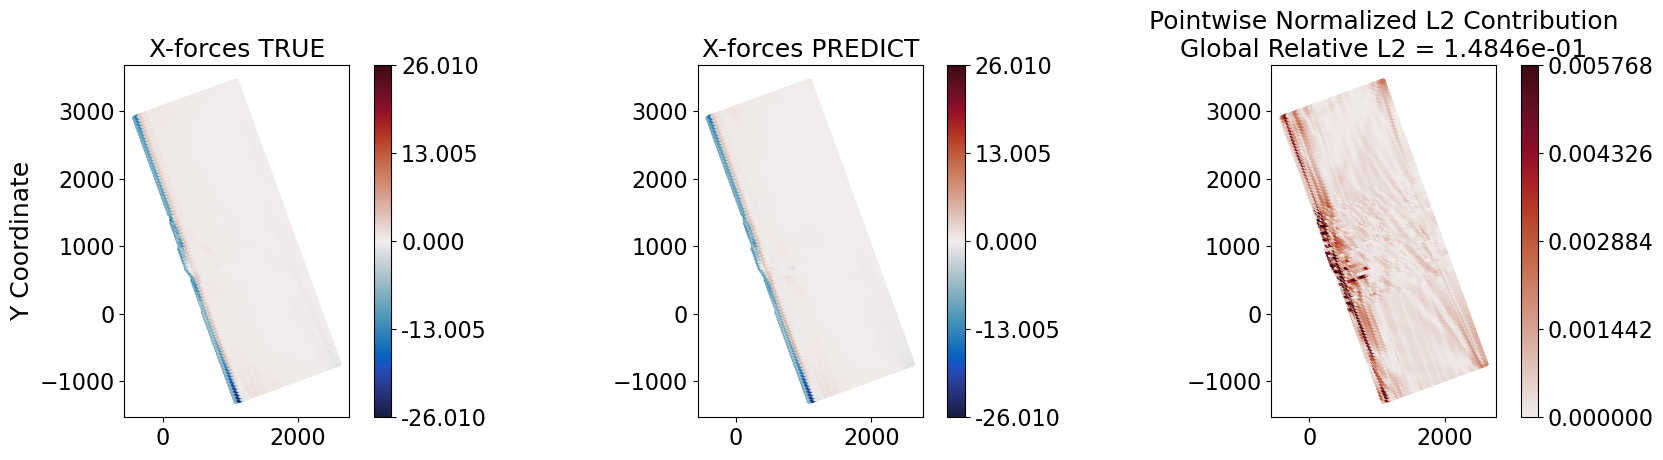

In [99]:
idex = 397
results = plot_prediction_comparison(

    true_vec=all_true[idex],
    pred_vec=all_pred[idex],

    xp_vector=xp_vector,
    yp_vector=yp_vector,

    valid_mask=all_valid[idex],

    valid_area_mask=validArea_mask,

    title_prefix='X-forces',

    pointwise_mode='normalized_l2',

    colorbar_mode='symmetric',

    vmax_error=None,
    err_cbar_max=99,

    cutoff_value=None,
    # physics_vmin=-0.5,
    # physics_vmax=0.5,

    point_size=8,

    num_ticks=5,
    # save_path = './Results/Xforces_prediction.pdf'
    
)

Hsig Relative L2 Error : 1.237572e-02
XForce Relative L2 Error: 5.787875e-02
YForce Relative L2 Error: 1.554300e-01


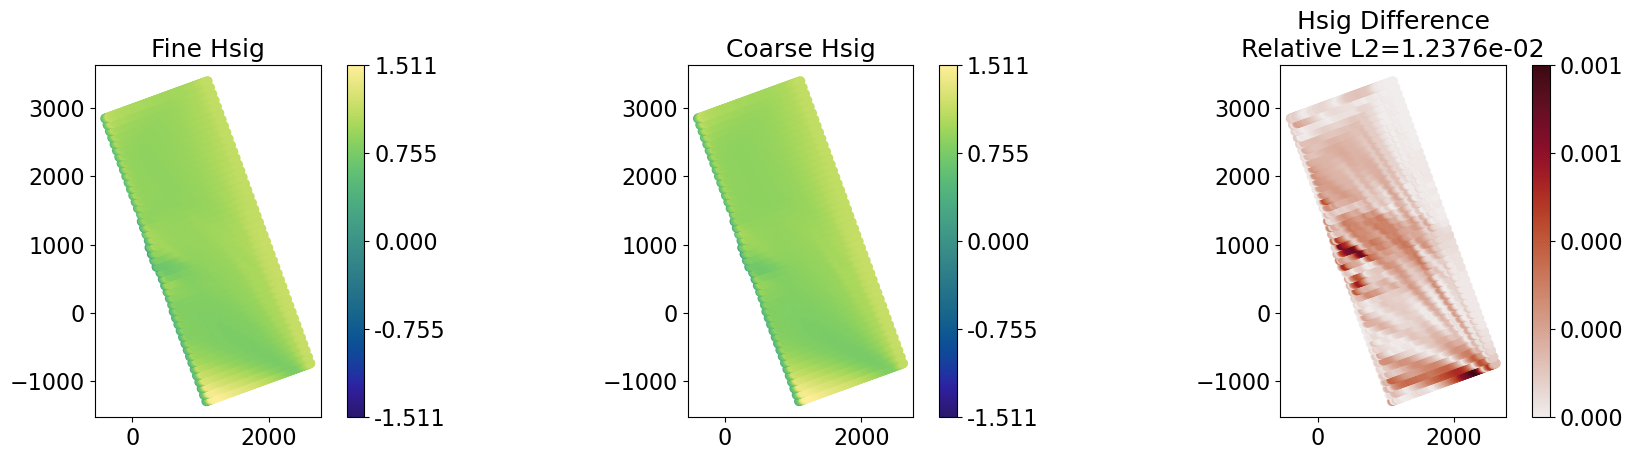

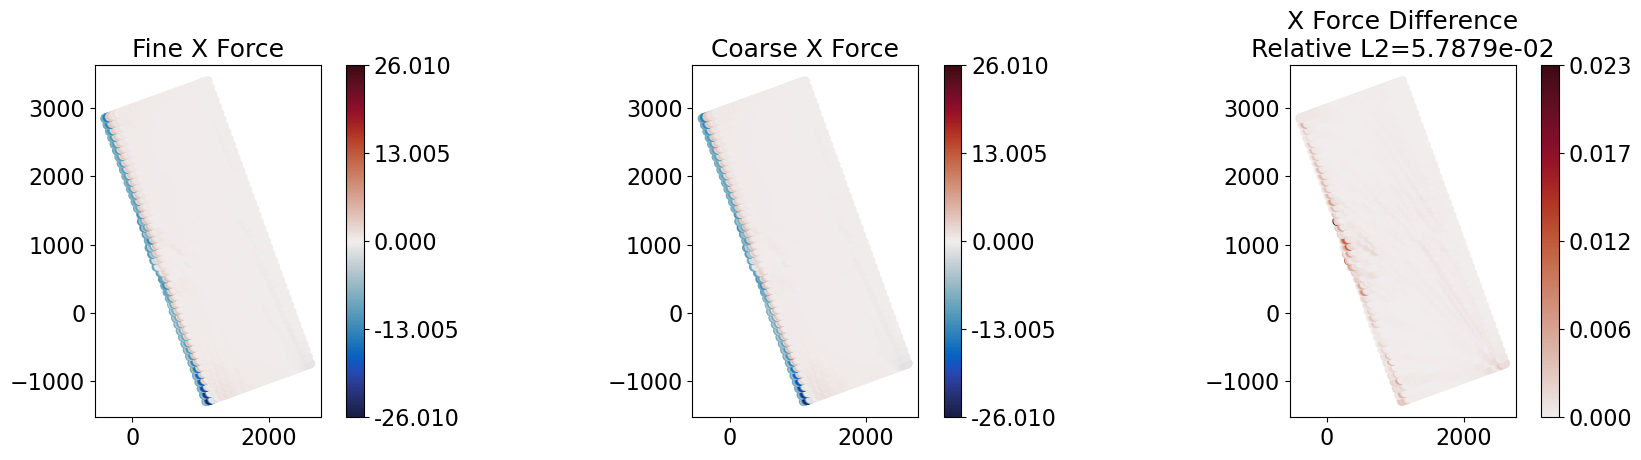

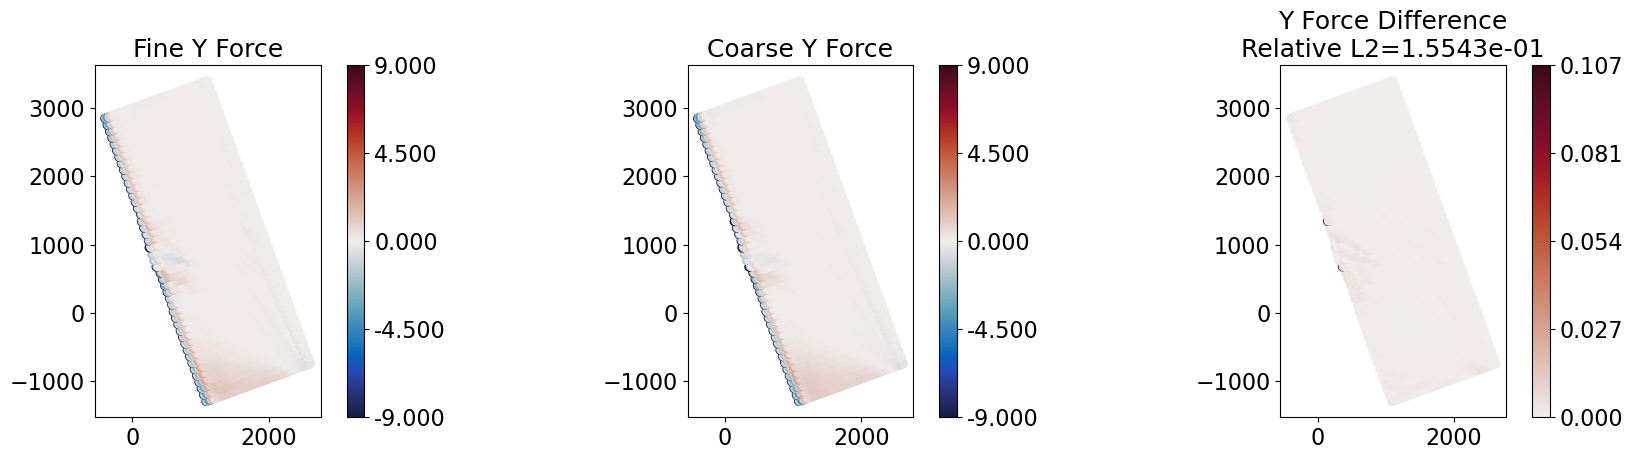

In [100]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(8, 0, 1.6, 160),
    colorbar_mode='symmetric',
    # save_dir = './Results/'
)

In [101]:
# results = compare_scenario(
#     coarse_grid=coarse_grid,
#     fine_grid=fine_grid,
#     overlap_info=overlap_info,
#     target_key=(8, 0, 1.6, 160),
#     colorbar_mode='symmetric',
#         physics_vmin=-1,
#     physics_vmax=1,
#     # save_dir = './Results/'
# )

## y-Forces

In [102]:
results_y = ModelAnalysis.compute_metrics_comprehensive(     
    test_df=test_df,
    xp_vector=xp_vector,
    yp_vector=yp_vector,
    model_dir="../Models/model_DUCK_yforces",
    component="y",)

/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

In [103]:
all_true = results_y["all_true_vectors"]
all_pred = results_y["all_pred_vectors"]
all_valid = results_y["all_valid_masks"]
new_rel_l2 = []

for i in range(len(all_true)):

    true_vec = all_true[i]
    pred_vec = all_pred[i]
    valid_mask = all_valid[i]

    mask = np.zeros(len(true_vec), dtype=bool)
    mask[validArea_mask] = True

    final_mask = valid_mask & mask

    diff = pred_vec[final_mask] - true_vec[final_mask]

    l2_diff = np.linalg.norm(diff)
    l2_true = np.linalg.norm(true_vec[final_mask])

    rel_l2 = l2_diff / l2_true

    new_rel_l2.append(rel_l2)

In [104]:
# data =  new_rel_l2
# mean_val = np.mean(data)
# median_val = np.median(data)

# # 2. Plotting
# plt.figure(figsize=(10, 6))
# plt.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# plt.title("Y-Force Model: Distribution of Relative $L_2$ Error", fontsize=14, fontweight='bold')
# plt.xlabel("Relative $L_2$ Error", fontsize=12)
# plt.ylabel("Number of Scenarios", fontsize=12)
# plt.grid(axis='y', alpha=0.3)
# plt.legend(loc='upper right')

# # Optional: Set x-axis limit if you want to focus on the bulk of data (0-30%)
# # plt.xlim(0, 30)

# plt.tight_layout()
# plt.savefig("./Results/Y-ForceModel_Distribution_RelativeL2Error.pdf")
# plt.show()

In [105]:
# 1. Convert to array and handle NaNs (if any)
arr = np.asarray(new_rel_l2)
valid_mask = np.isfinite(arr)

# 2. Get indices that sort the array in ascending order (Best to Worst)
sorted_indices = np.where(valid_mask)[0]
sorted_indices = sorted_indices[np.argsort(arr[valid_mask])]

# 3. Identify the Best 3 (lowest relative error)
best_3_indices = sorted_indices[:3]

# 4. Identify the Worst 3 (highest relative error)
# We take the last 3 and reverse them so the absolute worst is first
worst_3_indices = sorted_indices[-3:][::-1]

# --- Display Results ---

print("--- TOP 3 BEST SCENARIOS (Lowest L2 Error) ---")
for i, idx in enumerate(best_3_indices, 1):
    print(f"Rank {i}: Index {idx:4d} | Rel L2 Error: {arr[idx]:.2f}")

print("\n--- TOP 3 WORST SCENARIOS (Highest L2 Error) ---")
for i, idx in enumerate(worst_3_indices, 1):
    print(f"Rank {i}: Index {idx:4d} | Rel L2 Error: {arr[idx]:.2f}")

--- TOP 3 BEST SCENARIOS (Lowest L2 Error) ---
Rank 1: Index  481 | Rel L2 Error: 0.10
Rank 2: Index  548 | Rel L2 Error: 0.10
Rank 3: Index  297 | Rel L2 Error: 0.10

--- TOP 3 WORST SCENARIOS (Highest L2 Error) ---
Rank 1: Index  121 | Rel L2 Error: 0.21
Rank 2: Index  303 | Rel L2 Error: 0.21
Rank 3: Index  425 | Rel L2 Error: 0.21


In [106]:
print(np.mean(new_rel_l2))
print(np.max(new_rel_l2))
print(np.median(new_rel_l2))

0.13951183027550743
0.21037979394721806
0.12764542403236698


In [107]:
print(results_y['scenario_keys'][121])

(7, 315, 2.6, 160)


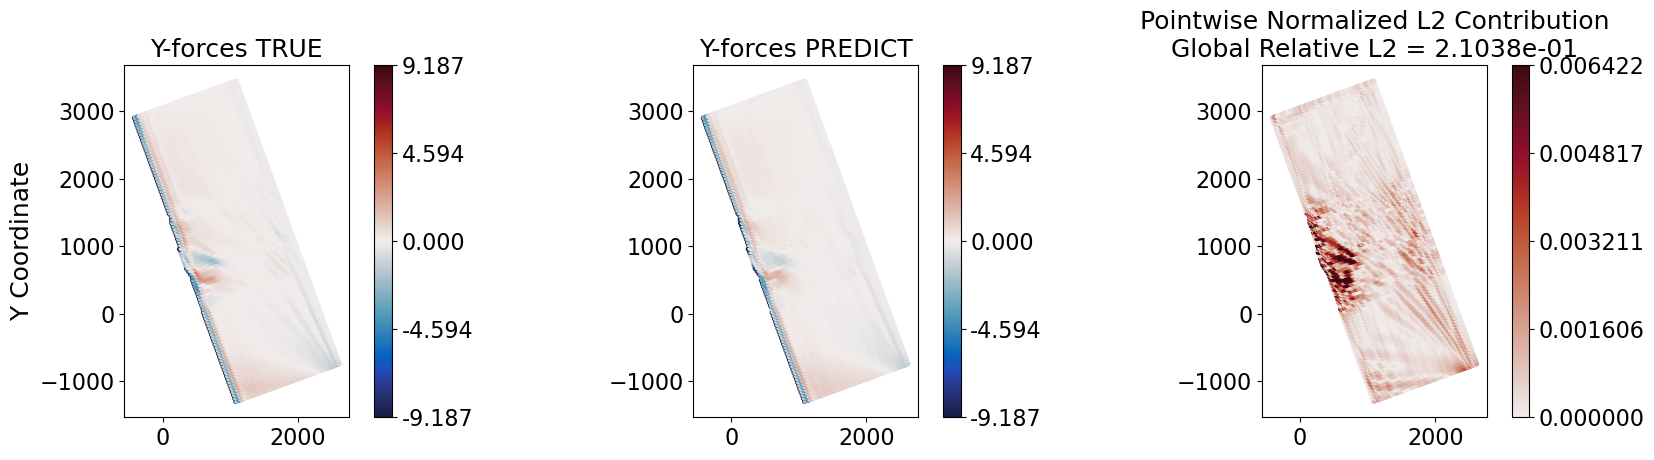

In [108]:
idex = 121
results = plot_prediction_comparison(

    true_vec=all_true[idex],
    pred_vec=all_pred[idex],

    xp_vector=xp_vector,
    yp_vector=yp_vector,

    valid_mask=all_valid[idex],

    valid_area_mask=validArea_mask,

    title_prefix='Y-forces',

    pointwise_mode='normalized_l2',

    colorbar_mode='symmetric',

    vmax_error=None,
    err_cbar_max=99,

    cutoff_value=None,


    point_size=8,

    num_ticks=5,
    # save_path = './Results/Yforces_prediction.pdf'
    
)


Hsig Relative L2 Error : 1.088490e-02
XForce Relative L2 Error: 5.006446e-02
YForce Relative L2 Error: 1.678798e-01


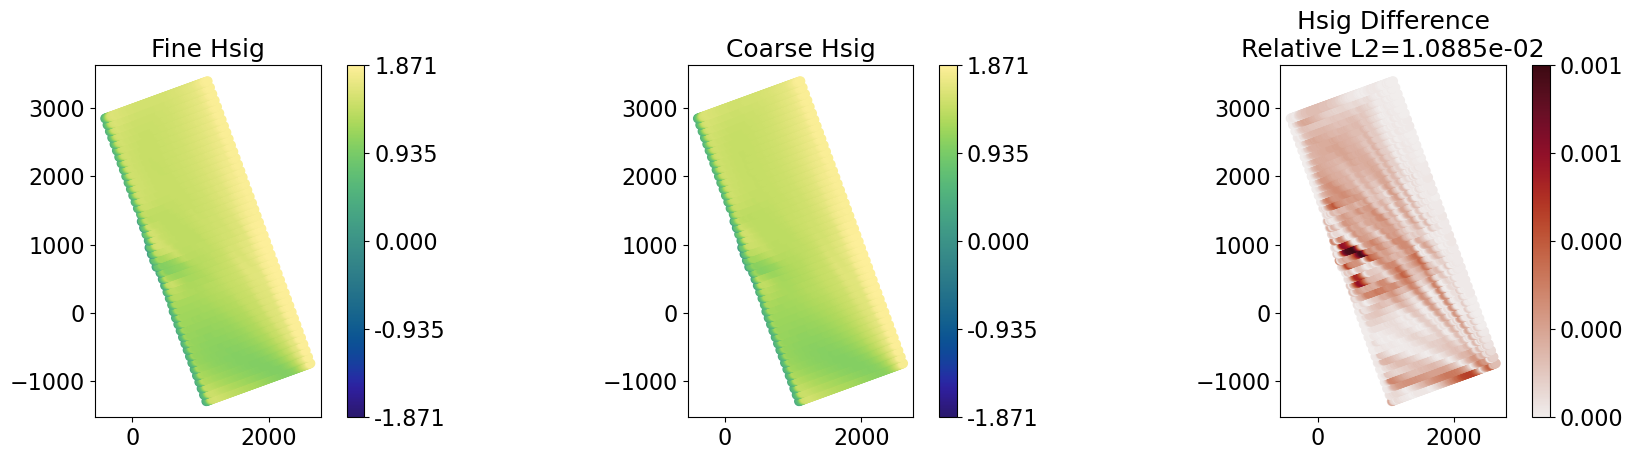

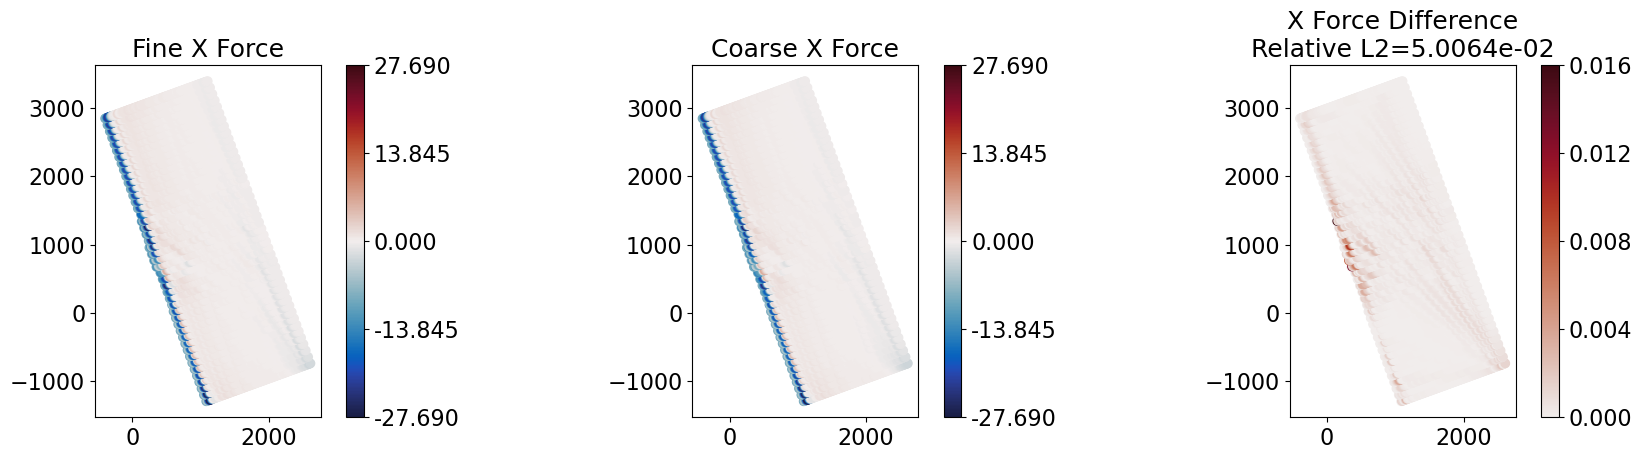

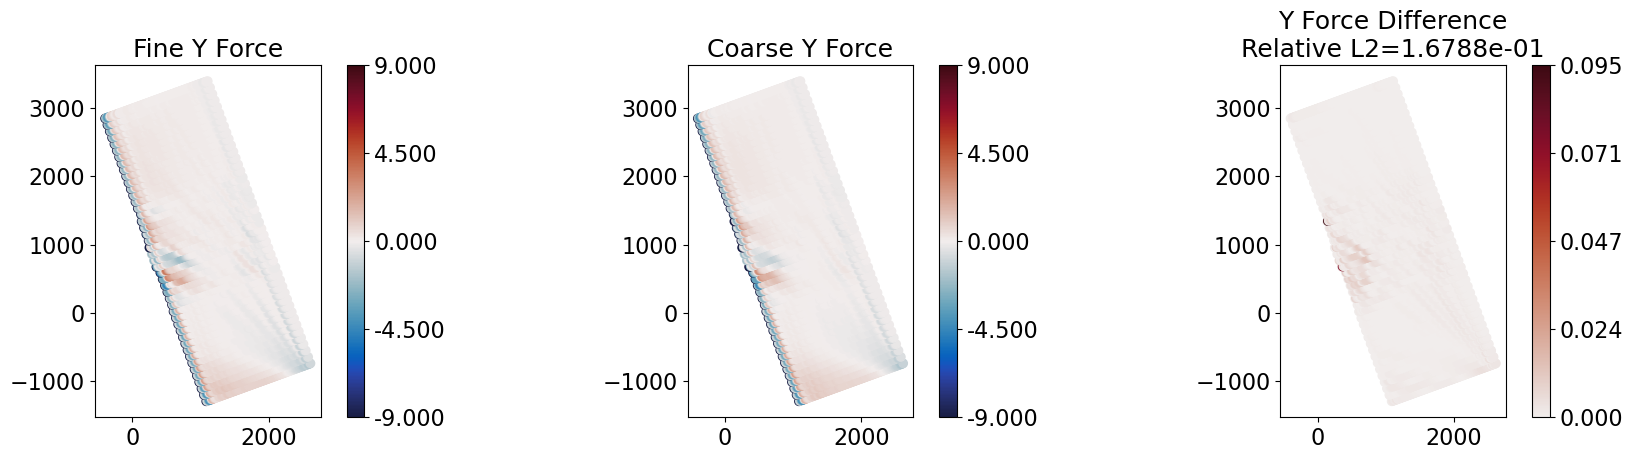

In [109]:
results = compare_scenario(
    coarse_grid=coarse_grid,
    fine_grid=fine_grid,
    overlap_info=overlap_info,
    target_key=(7, 315, 2.6, 160),
    colorbar_mode='symmetric',
    # save_dir = './Results/'
)